In [2]:
import cv2
import numpy as np
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import display, Image, clear_output 
import time
import json 
import random

In [4]:
# Load camera parameters from Part 1 (copied from user request)
final_camera_parameters = {
    'focal_length_x': 2058.726643689176,
     'focal_length_y': 2058.726643689176,
     'principal_point_x': 960.0,
     'principal_point_y': 540.0,
     'vanishing_point': (933.1003894333489, 153.07230492201563),
     'camera_height_pixels': 446.92769507798437,
     'pixel_distance_at_reference': 759.2571948055397,
     'reference_y': 600,
     'known_distance_meters': 14.5,
     'image_width': 1920,
     'image_height': 1080
}

print("Camera Parameters Loaded:")
# Pretty print the dictionary
print(json.dumps(final_camera_parameters, indent=4))

# Define video path from Part 1
video_path = './input_videos/cars_road_3.mp4'
output_video_path = './output_videos/part3_detections.mp4'
output_detections_path = './output_data/part3_detections.json'

# Create output directories if they don't exist
os.makedirs(os.path.dirname(output_video_path), exist_ok=True)
os.makedirs(os.path.dirname(output_detections_path), exist_ok=True)

print(f"Input video: {video_path}")
print(f"Output video will be saved to: {output_video_path}")
print(f"Detections data will be saved to: {output_detections_path}")

Camera Parameters Loaded:
{
    "focal_length_x": 2058.726643689176,
    "focal_length_y": 2058.726643689176,
    "principal_point_x": 960.0,
    "principal_point_y": 540.0,
    "vanishing_point": [
        933.1003894333489,
        153.07230492201563
    ],
    "camera_height_pixels": 446.92769507798437,
    "pixel_distance_at_reference": 759.2571948055397,
    "reference_y": 600,
    "known_distance_meters": 14.5,
    "image_width": 1920,
    "image_height": 1080
}
Input video: ./input_videos/cars_road_3.mp4
Output video will be saved to: ./output_videos/part3_detections.mp4
Detections data will be saved to: ./output_data/part3_detections.json


## Detection
detecting vehciles inside a pre-defined ROI using the Yolo model. saving the boudning boxes

In [25]:
# Define ROI filtering function
def is_in_roi(bbox, roi_polygon):
    # Get center point of bbox
    center_x = (bbox[0] + bbox[2]) / 2
    center_y = (bbox[3]) # Use bottom of box (where it touches the road)
    center_point = (center_x, center_y)
    
    # Check if point is inside polygon
    return cv2.pointPolygonTest(roi_polygon, center_point, False) >= 0

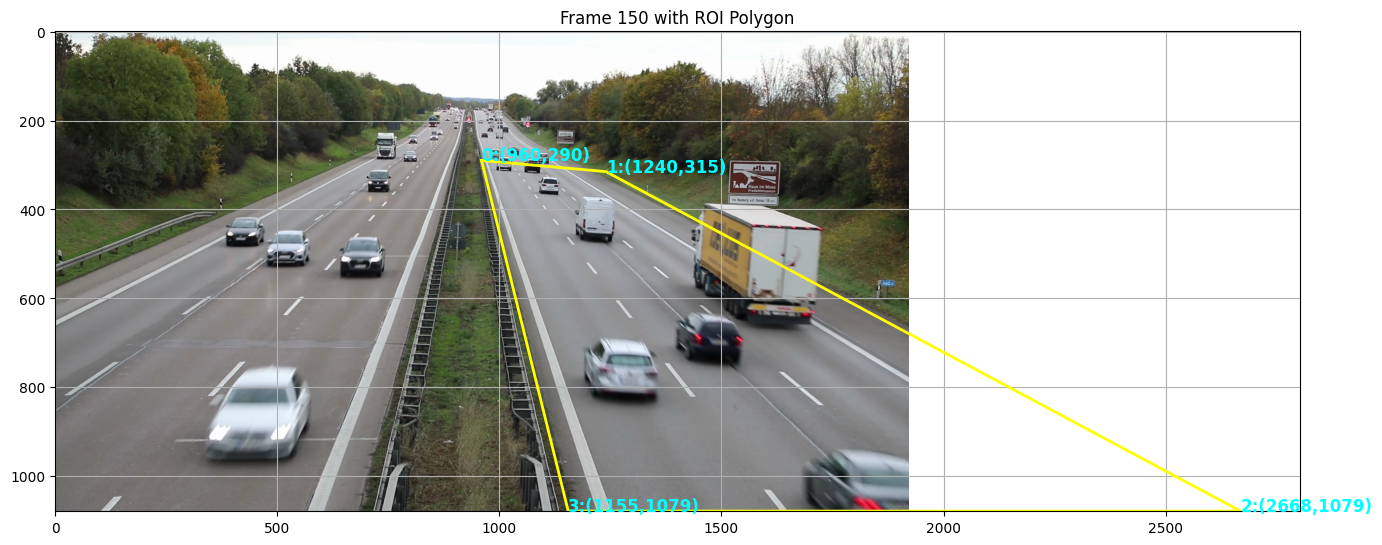

In [5]:
# --- ROI Visualization Test ---
# Load a single frame from video
video_path = './input_videos/cars_road_3.mp4'
cap = cv2.VideoCapture(video_path)
target_frame_number = 150
cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame_number)
ret, frame = cap.read()
cap.release()
# Define the ROI polygon (adjust coordinates as needed)
roi_polygon = np.array([    [960, 290],
    [1240, 315],
    [2668, 1079],
    [1155, 1079]], np.int32)
if ret:
    # Convert BGR to RGB for plotting
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Plotting with matplotlib
    plt.figure(figsize=(14, 8))
    plt.imshow(frame_rgb)
    plt.title(f"Frame {target_frame_number} with ROI Polygon")
    
    # Draw the polygon
    poly_closed = np.vstack([roi_polygon, roi_polygon[0]])  # Close the loop
    plt.plot(poly_closed[:, 0], poly_closed[:, 1], color='yellow', linewidth=2)

    # Optionally, label the vertices
    for idx, (x, y) in enumerate(roi_polygon):
        plt.text(x, y, f'{idx}:({x},{y})', color='cyan', fontsize=12, weight='bold')

    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Failed to read frame from video")

In [33]:
# Load the YOLOv8 model (using a standard pre-trained model)
# You might need to run '!pip install ultralytics' if you haven't already
model = YOLO('yolov8n.pt')  # Using yolov8n for speed, can change to yolov8s, yolov8m, etc. for better accuracy

# Open the video file
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print(f"Error: Could not open video file: {video_path}")
    # Handle error appropriately, maybe raise an exception
    raise FileNotFoundError(f"Video file not found or cannot be opened: {video_path}")
else:
    # Get video properties
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    # Calculate the number of frames for the first n seconds

        # Define the time range to process (in seconds)
    start_time = 5  # Start processing from 5 seconds into the video
    end_time = 15   # Process until 15 seconds into the video
    start_frame = int(start_time * fps)
    end_frame = int(end_time * fps)
    frames_to_process =  end_frame - start_frame
    
    # Get total frame count for reference, but we'll stop early
    total_frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Video Properties - Resolution: {frame_width}x{frame_height}, FPS: {fps:.2f}, Total Frames: {total_frame_count}")
    print(start_frame, end_frame, frames_to_process)

    # Define the codec and create VideoWriter object (adjust output filename if desired)
    # output_video_path_trimmed = './output_videos/part3_detections_12s.mp4'
    # output_detections_path_trimmed = './output_data/part3_detections_12s.json'
    # Using original paths for now, will overwrite previous output
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))
    
    # Store detections
    all_detections = {} # Dictionary to store detections per frame: {frame_idx: [detection1, detection2, ...]}

    frame_idx = 0

    # Skip to the start frame
    for _ in range(start_frame):
        ret = cap.read()[0]
        if not ret:
            print(f"\nEnd of video reached before start frame {start_frame}.")
            break
        frame_idx += 1

    while frame_idx < end_frame:            
        ret, frame = cap.read()
        if not ret:
            print(f"\nEnd of video reached or error reading frame {frame_idx+1} before reaching {frames_to_process} frames.")
            break

        # Perform inference
        results = model(frame, verbose=False, classes=[2, 5, 7]) 

        # Process results
        frame_detections = []
        if results:
            processed_result = results[0] 
            if processed_result.boxes is not None and len(processed_result.boxes) > 0:
                bboxes = processed_result.boxes.xyxy.cpu().numpy()
                confidences = processed_result.boxes.conf.cpu().numpy()
                classes = processed_result.boxes.cls.cpu().numpy()
                    
                for idx, bbox in enumerate(bboxes):
                    x1, y1, x2, y2 = map(int, bbox)
                    class_id = int(classes[idx])
                    confidence = float(confidences[idx])
                        
                    # Only add detections that are in the ROI
                    if is_in_roi([x1, y1, x2, y2], roi_polygon):
                        # Draw bounding box on frame (for visualization)
                        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                        label = f"{class_id}: {confidence:.2f}"
                        cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                            
                        # Add to detections list
                        frame_detections.append({
                            'bbox': [x1, y1, x2, y2],
                            'confidence': confidence,
                            'class_id': class_id
                        })
        
        # Draw ROI polygon on the frame
        cv2.polylines(frame, [roi_polygon.reshape(-1, 1, 2)], True, (0, 255, 255), 2)
        # Store detections for the current frame
        if frame_detections:
             all_detections[frame_idx] = frame_detections

        # Write the frame to the output video
        out.write(frame)

        # Optional: Display progress
        if (frame_idx - start_frame + 1) % 50 == 0 or frame_idx == start_frame:
            print(f"Processed frame {frame_idx} ({frame_idx - start_frame + 1}/{frames_to_process})")

        frame_idx += 1

    # Release everything when job is finished
    cap.release()
    out.release()
    print(f"Finished processing {frame_idx} frames. Output video saved to {output_video_path}")

    # Save detections to JSON file
    try:
        with open(output_detections_path, 'w') as f:
            json.dump(all_detections, f, indent=4)
        print(f"Detections saved to {output_detections_path}")
    except Exception as e:
        print(f"Error saving detections to JSON: {e}")

# Indicate completion
print(f"Part 3: Vehicle detection for seconds {start_time} to {end_time} complete.")


Video Properties - Resolution: 1920x1080, FPS: 25.00, Total Frames: 1060
125 375 250
Starting vehicle detection for the first 250 frames...
Processed frame 125 (1/250)
Processed frame 174 (50/250)
Processed frame 224 (100/250)
Processed frame 274 (150/250)
Processed frame 324 (200/250)
Processed frame 374 (250/250)
Finished processing 375 frames. Output video saved to ./output_videos/part3_detections.mp4
Detections saved to ./output_data/part3_detections.json
Part 3: Vehicle detection for seconds 5 to 15 complete.


## Tracking
tracking vehciles using the SORT algorithm

In [73]:
# %% [code]
from sort import Sort # Make sure sort.py is in the correct path or installed

# --- Configuration ---
output_online_sort_video_path = './output_videos/online_sort_tracking.mp4'
os.makedirs(os.path.dirname(output_online_sort_video_path), exist_ok=True)

output_track_history_path = './output_data/track_history.json' # Define output path for history
os.makedirs(os.path.dirname(output_track_history_path), exist_ok=True) # Ensure directory exists

# Use the ROI defined earlier
# roi_polygon = np.array([...], dtype=np.int32)

# Use the YOLO model loaded earlier
model = YOLO('yolov8n.pt') # Or the specific model loaded previously

score_threshold = 0.4 # Confidence threshold for detections fed to SORT
sort_max_age = 1      # Max frames to keep track without detection
sort_min_hits = 3     # Min consecutive hits to start track
sort_iou_threshold = 0.3 # IOU threshold for matching

start_time = 5  # in seconds
end_time = 20   # in seconds
start_frame = int(start_time * fps)
end_frame = int(end_time * fps)
frames_to_process =  end_frame - start_frame

# --- Initialization ---
cap_online = cv2.VideoCapture(video_path)
if not cap_online.isOpened():
    print(f"Error: Could not open video file {video_path}")
else:

    frame_width = int(cap_online.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap_online.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap_online.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_online = cv2.VideoWriter(output_online_sort_video_path, fourcc, fps, (frame_width, frame_height))
    KalmanBoxTracker.count = 0
    # Initialize SORT tracker with parameters
    sort_tracker_online = Sort(max_age=sort_max_age, min_hits=sort_min_hits, iou_threshold=sort_iou_threshold)

    # Store trajectories (optional, for drawing lines)
    trajectories_online = {}
    track_colors = {} # Assign a random color to each track ID

    track_history = {} # Dictionary to store track history {track_id: [(frame_idx, bbox), ...]}
    
    frame_idx_online = 0
    start_time_proc = time.time()

    # --- Processing Loop ---

    # Skip to the start frame
    for _ in range(start_frame):
        ret = cap_online.read()[0]
        if not ret:
            print(f"\nEnd of video reached before start frame {start_frame}.")
            break
        frame_idx_online += 1
    while frame_idx_online < end_frame:
        ret, frame = cap_online.read()
        if not ret:
            print("\nEnd of video reached or error reading frame.")
            break

        # Perform YOLO inference
        results = model(frame, verbose=False) # verbose=False to reduce console spam

        detections_current_frame = []
        boxes = results[0].boxes.xyxy.cpu().numpy()
        scores = results[0].boxes.conf.cpu().numpy()
        classes = results[0].boxes.cls.cpu().numpy().astype(int)

        for i in range(len(boxes)):
            # Filter by class and score threshold
            if  scores[i] >= score_threshold:
                x1, y1, x2, y2 = boxes[i]
                score = scores[i]
                # Format for SORT: [x1, y1, x2, y2, score]

                # --- ROI Filtering (Optional - apply before or after SORT) ---
                center_x = (x1 + x2) / 2
                bottom_y = y2 # Use bottom of box
                if cv2.pointPolygonTest(roi_polygon, (center_x, bottom_y), False) >= 0:
                     detections_current_frame.append([x1, y1, x2, y2, score])
                # detections_current_frame.append([x1, y1, x2, y2, score])

        # Update SORT tracker
        if len(detections_current_frame) > 0:
            tracked_objects = sort_tracker_online.update(np.array(detections_current_frame))
        else:
            # Provide empty array if no detections
            tracked_objects = sort_tracker_online.update(np.empty((0, 5)))



        # --- Visualization ---
        # Draw ROI
        cv2.polylines(frame, [roi_polygon], True, (0, 255, 255), 2) # Yellow ROI

        for track in tracked_objects:
            x1, y1, x2, y2, track_id = map(int, track)

            # --- Record Track History ---
            bbox = (x1, y1, x2, y2) # Current bounding box
            # Use frame_idx_online which should be tracking the current frame number in this loop
            frame_data = (frame_idx_online, bbox) # Data point: frame index and bbox
    
            if track_id not in track_history:
                track_history[track_id] = []
            track_history[track_id].append(frame_data)
            # --- End Record Track History ---
            
            # Assign color to new track ID
            if track_id not in track_colors:
                track_colors[track_id] = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
            color = track_colors[track_id]

            # Draw bounding box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            label = f"ID: {track_id}"
            cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            # Update and draw trajectory (optional)
            center = (int((x1 + x2) / 2), int((y1 + y2) / 2))
            if track_id not in trajectories_online:
                trajectories_online[track_id] = []
            trajectories_online[track_id].append(center)

            # Draw last N points of trajectory
            if len(trajectories_online[track_id]) > 1:
                 # Limit trajectory length drawn to avoid clutter
                history_len = min(len(trajectories_online[track_id]), 50)
                for j in range(1, history_len):
                     idx = len(trajectories_online[track_id]) - j
                     pt1 = trajectories_online[track_id][idx - 1]
                     pt2 = trajectories_online[track_id][idx]
                     cv2.line(frame, pt1, pt2, color, 2)


        # Add frame counter
        cv2.putText(frame, f"Frame: {frame_idx_online}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

        # Write frame to output video
        out_online.write(frame)

        frame_idx_online += 1

        # Display progress
        if frame_idx_online % 50 == 0:
            elapsed_time = time.time() - start_time_proc
            fps_proc = frame_idx_online / elapsed_time if elapsed_time > 0 else 0
            print(f"Processed frame {frame_idx_online} ({fps_proc:.2f} FPS)")


    # --- Cleanup ---
    cap_online.release()
    out_online.release()
    end_time_proc = time.time()
    total_time = end_time_proc - start_time_proc
    avg_fps = frame_idx_online / total_time if total_time > 0 else 0

    serializable_history = {}
    for tid, history in track_history.items():
         serializable_history[str(tid)] = [(int(f_idx), [int(coord) for coord in bb]) for f_idx, bb in history]

    with open(output_track_history_path, 'w') as f:
        json.dump(serializable_history, f, indent=4)
    print("Track history saved successfully.")

    print(f"\nFinished online SORT tracking.")
    print(f"Processed {frame_idx_online} frames in {total_time:.2f} seconds (Avg FPS: {avg_fps:.2f}).")
    print(f"Tracked video saved to {output_online_sort_video_path}")
    print(f"Total unique vehicle IDs tracked: {len(track_colors)}")


Processed frame 150 (90.31 FPS)
Processed frame 200 (45.62 FPS)
Processed frame 250 (35.64 FPS)
Processed frame 300 (31.83 FPS)
Processed frame 350 (29.60 FPS)
Processed frame 400 (27.85 FPS)
Processed frame 450 (26.92 FPS)
Processed frame 500 (26.24 FPS)
5
4
3
2
1
6
7
8
13
15
22
21
23
24
25
26
28
30
31
32
34
35
36
37
38
40
42
46
47
48
49
52
53
54
56
59
62
60
65
66
67
68
70
71
72
75
76
80
81
84
83
Track history saved successfully.

Finished online SORT tracking.
Processed 500 frames in 19.06 seconds (Avg FPS: 26.23).
Tracked video saved to ./output_videos/online_sort_tracking.mp4
Total unique vehicle IDs tracked: 51


##  Keypoint (Taillight) Detection

In [74]:
# --- Parameters ---
# HSV Color Range for Taillights (Red/Orange) - NEEDS TUNING!
# These are common ranges, but you MUST adjust them based on your video
# Hue range for red wraps around 0/180 in HSV
lower_red1 = np.array([0, 90, 90])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([165, 90, 90]) # Also adjust second range if used
upper_red2 = np.array([180, 255, 255])

# SimpleBlobDetector Parameters - NEEDS TUNING!
blob_params = cv2.SimpleBlobDetector_Params()
# Filter by Color (already done by HSV thresholding)
blob_params.filterByColor = False
# Filter by Area (adjust min/max based on expected taillight size in pixels)
blob_params.filterByArea = True
blob_params.minArea = 10  # Example: Minimum area in pixels
blob_params.maxArea = 500 # Example: Maximum area in pixels
# Filter by Circularity (taillights might be somewhat circular/oval)
blob_params.filterByCircularity = True
blob_params.minCircularity = 0.2 # Example
# Filter by Convexity (shape property)
blob_params.filterByConvexity = True
blob_params.minConvexity = 0.4 # Example
# Filter by Inertia (elongation, lower value means more elongated)
blob_params.filterByInertia = True
blob_params.minInertiaRatio = 0.05 # Example
blob_detector = cv2.SimpleBlobDetector_create(blob_params)

# Symmetry/Positioning Parameters - NEEDS TUNING!
# vertical_pos_threshold = 0.5 # Expect taillights in the bottom half (0.5) of the bbox height
horizontal_sym_tolerance = 0.3 # Allow deviation from perfect horizontal symmetry relative to bbox width

output_keypoint_history_path = './output_data/part5_keypoint_history.json'
os.makedirs(os.path.dirname(output_keypoint_history_path), exist_ok=True)

# --- Load Data ---
print(f"Loading track history from: {output_track_history_path}")
try:
    with open(output_track_history_path, 'r') as f:
        track_history = json.load(f)
    # Convert keys back to int if needed (depends on how it was saved)
    track_history = {int(k): v for k, v in track_history.items()}
    print(f"Loaded history for {len(track_history)} tracks.")
except FileNotFoundError:
    print(f"Error: Track history file not found at {output_track_history_path}")
    # Handle error appropriately, maybe raise exception or exit
    raise
except Exception as e:
    print(f"Error loading track history: {e}")
    raise

# --- Initialize ---
keypoint_history = {} # {track_id: [(frame_idx, left_kp, right_kp), ...]} left_kp/right_kp = (x, y) or None
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print(f"Error: Could not open video file {video_path}")
    raise FileNotFoundError(f"Video file not found or cannot be opened: {video_path}")

total_frames_to_process = sum(len(hist) for hist in track_history.values())
processed_frames_count = 0
start_time_kp = time.time()

print(f"Processing {total_frames_to_process} tracked bounding boxes...")

# --- Process Tracks ---
for track_id, history in track_history.items():
    keypoint_history[track_id] = []
    print(f"Processing Track ID: {track_id} ({len(history)} boxes)")

    for frame_idx, bbox in history:
        processed_frames_count += 1
        if processed_frames_count % 100 == 0:
             elapsed = time.time() - start_time_kp
             fps = processed_frames_count / elapsed if elapsed > 0 else 0
             print(f"  Processed {processed_frames_count}/{total_frames_to_process} boxes... ({fps:.2f} boxes/sec)")

        # Seek to the correct frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            print(f"  Warning: Could not read frame {frame_idx} for track {track_id}. Skipping.")
            keypoint_history[track_id].append((frame_idx, None, None))
            continue

        # Extract bounding box coordinates
        x1, y1, x2, y2 = map(int, bbox)

        # Ensure coordinates are valid
        if x1 >= x2 or y1 >= y2 or x1 < 0 or y1 < 0 or x2 > frame.shape[1] or y2 > frame.shape[0]:
             print(f"  Warning: Invalid bbox {bbox} at frame {frame_idx} for track {track_id}. Skipping.")
             keypoint_history[track_id].append((frame_idx, None, None))
             continue

        # Crop the frame to the bounding box
        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            print(f"  Warning: Empty crop from bbox {bbox} at frame {frame_idx} for track {track_id}. Skipping.")
            keypoint_history[track_id].append((frame_idx, None, None))
            continue

        # --- Taillight Detection within Crop ---
        hsv_crop = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)

        # Apply HSV thresholding (combine masks for wrapped red hue)
        mask1 = cv2.inRange(hsv_crop, lower_red1, upper_red1)
        mask2 = cv2.inRange(hsv_crop, lower_red2, upper_red2)
        mask = cv2.bitwise_or(mask1, mask2)

        # Optional: Morphological operations to clean mask
        # kernel = np.ones((3,3), np.uint8)
        # mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        # mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # Detect blobs
        keypoints = blob_detector.detect(mask)

        # --- Filter blobs to find likely taillight pair ---
        left_kp, right_kp = None, None
        potential_kps = []
        crop_h, crop_w = crop.shape[:2]
        crop_center_x = crop_w / 2

        # Filter blobs by vertical position and store coordinates relative to full frame
        for kp in keypoints:
            kp_x_crop, kp_y_crop = kp.pt
            if kp_y_crop > crop_h * vertical_pos_threshold: # Check if in lower part
                # Convert keypoint coordinates from crop-relative to frame-relative
                kp_x_frame = x1 + kp_x_crop
                kp_y_frame = y1 + kp_y_crop
                potential_kps.append(((kp_x_frame, kp_y_frame), kp_x_crop)) # Store frame coords and crop x-coord for symmetry check

        # Look for a symmetrical pair
        if len(potential_kps) >= 2:
            best_pair = None
            min_sym_error = float('inf')

            # Iterate through all pairs (simple O(n^2) approach)
            for i in range(len(potential_kps)):
                for j in range(i + 1, len(potential_kps)):
                    kp1_frame, kp1_x_crop = potential_kps[i]
                    kp2_frame, kp2_x_crop = potential_kps[j]

                    # Check horizontal symmetry within tolerance
                    center_diff1 = abs(kp1_x_crop - crop_center_x)
                    center_diff2 = abs(kp2_x_crop - crop_center_x)
                    symmetry_error = abs(center_diff1 - center_diff2) / crop_w

                    if symmetry_error < horizontal_sym_tolerance:
                        # Check vertical alignment (optional, could add tolerance here too)
                        # if abs(kp1_frame[1] - kp2_frame[1]) < vertical_alignment_tolerance:
                            if symmetry_error < min_sym_error: # Find the most symmetrical pair
                                min_sym_error = symmetry_error
                                # Assign left/right based on x-coordinate in the crop
                                if kp1_x_crop < kp2_x_crop:
                                    best_pair = (kp1_frame, kp2_frame)
                                else:
                                    best_pair = (kp2_frame, kp1_frame)

            if best_pair:
                left_kp, right_kp = best_pair

        # Store results for this frame
        keypoint_history[track_id].append((frame_idx, left_kp, right_kp))

# --- Cleanup ---
cap.release()
end_time_kp = time.time()
total_time_kp = end_time_kp - start_time_kp
avg_fps_kp = processed_frames_count / total_time_kp if total_time_kp > 0 else 0

print(f"\n--- Finished Keypoint Detection ---")
print(f"Processed {processed_frames_count} boxes in {total_time_kp:.2f} seconds (Avg: {avg_fps_kp:.2f} boxes/sec).")

# --- Save Keypoint History ---
print(f"Saving keypoint history to {output_keypoint_history_path}...")
try:
    # Convert tuples to lists for JSON serialization
    serializable_kp_history = {}
    for tid, history in keypoint_history.items():
        serializable_kp_history[str(tid)] = []
        for f_idx, l_kp, r_kp in history:
            l_kp_list = list(map(int, l_kp)) if l_kp else None
            r_kp_list = list(map(int, r_kp)) if r_kp else None
            serializable_kp_history[str(tid)].append([int(f_idx), l_kp_list, r_kp_list])

    with open(output_keypoint_history_path, 'w') as f:
        json.dump(serializable_kp_history, f, indent=4)
    print("Keypoint history saved successfully.")
except Exception as e:
    print(f"Error saving keypoint history: {e}")


# You can now optionally add visualization code here or in a new cell
# to load the keypoint history and draw the points on sample frames.

Loading track history from: ./output_data/track_history.json
Loaded history for 51 tracks.
Processing 2222 tracked bounding boxes...
Processing Track ID: 5 (11 boxes)
Processing Track ID: 4 (14 boxes)
Processing Track ID: 3 (20 boxes)
Processing Track ID: 2 (55 boxes)
  Processed 100/2222 boxes... (4.68 boxes/sec)
Processing Track ID: 1 (50 boxes)
Processing Track ID: 6 (83 boxes)
  Processed 200/2222 boxes... (4.51 boxes/sec)
Processing Track ID: 7 (19 boxes)
Processing Track ID: 8 (68 boxes)
  Processed 300/2222 boxes... (4.23 boxes/sec)
Processing Track ID: 13 (87 boxes)
  Processed 400/2222 boxes... (3.95 boxes/sec)
Processing Track ID: 15 (23 boxes)
Processing Track ID: 22 (37 boxes)
Processing Track ID: 21 (28 boxes)
Processing Track ID: 23 (49 boxes)
  Processed 500/2222 boxes... (3.78 boxes/sec)
Processing Track ID: 24 (7 boxes)
Processing Track ID: 25 (3 boxes)
Processing Track ID: 26 (15 boxes)
Processing Track ID: 28 (157 boxes)
  Processed 600/2222 boxes... (3.63 boxes/sec)

--- Starting Corrected Keypoint Sequence Verification Visualization (v3) ---
Loading keypoint history...
Loaded keypoint history for 51 tracks.
Loading track (bounding box) history...
Loaded bounding box history for 51 tracks.

Searching for sequences (length=3) meeting CORRECTED criteria...
Criteria: Y_align_diff <= 15, 20 <= X_dist <= 150, frame_gap <= 1

Found 137 total valid sequences meeting corrected criteria.
Visualizing 9 sequences from unique cars...


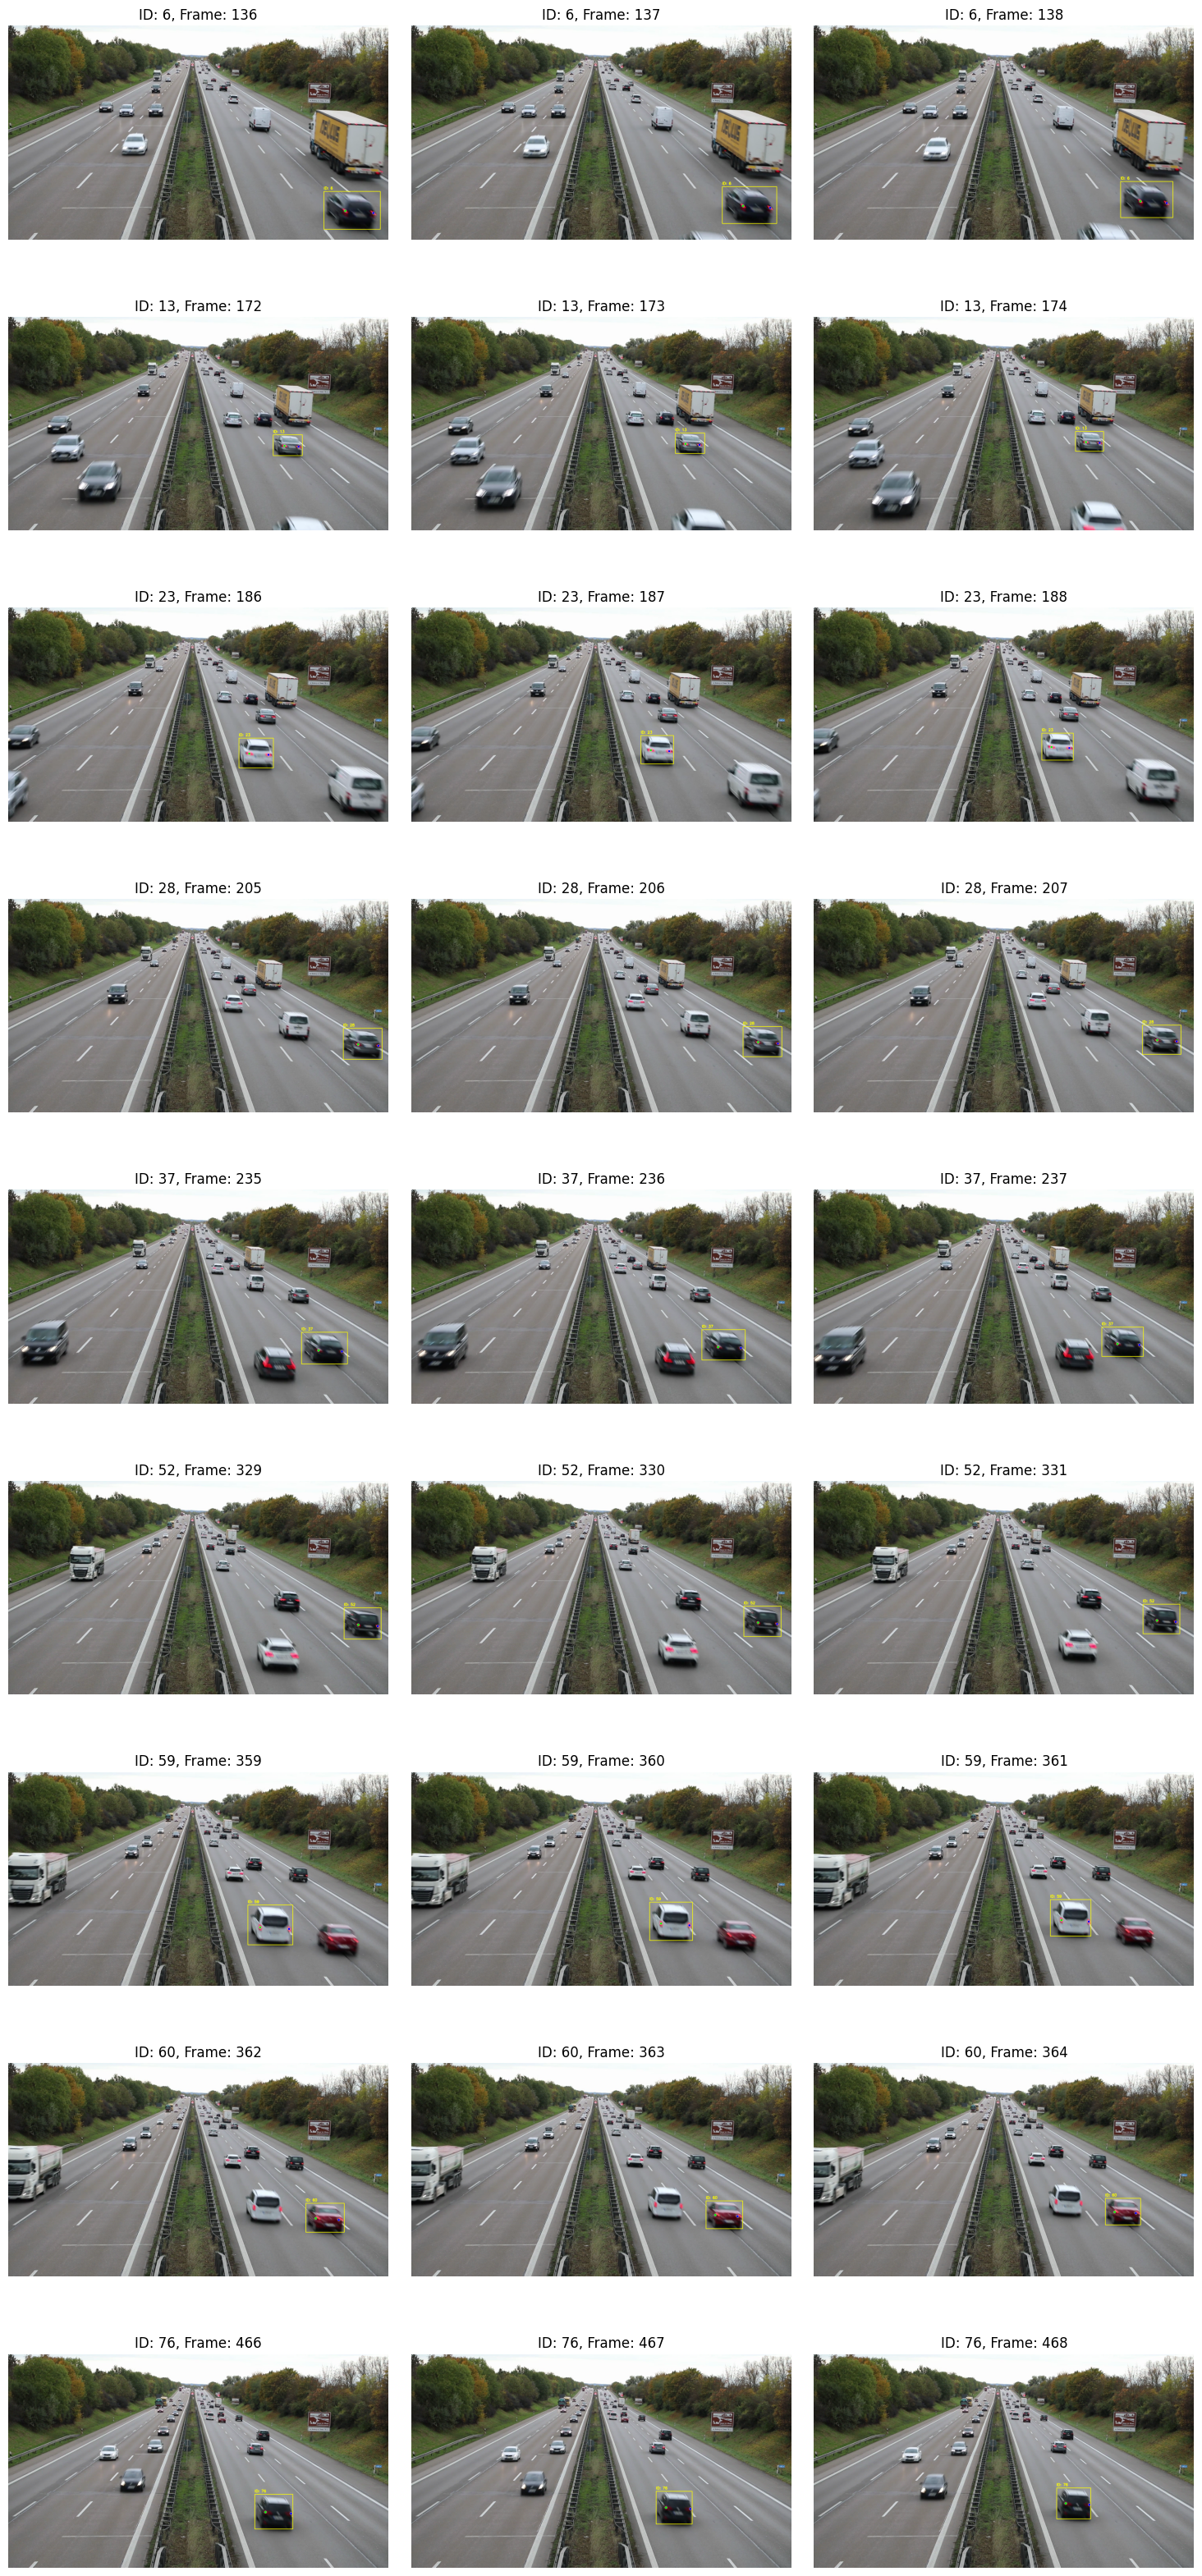


--- Corrected Sequence Verification Visualization Complete ---


In [8]:
import cv2
import numpy as np
import json
import random
import matplotlib.pyplot as plt
import os

print("--- Starting Corrected Keypoint Sequence Verification Visualization (v3) ---")

# --- Parameters ---
sequence_length_to_show = 3
num_sequences_to_visualize = 20 # Max unique cars to try and show
max_frame_gap = 1

# Y-Axis Alignment Parameters (Checking vertical alignment)
max_vertical_alignment_diff_pixels = 15 # Max allowed Y difference between L/R points

# X-Axis Distance Parameters (Checking horizontal separation)
min_horizontal_distance_pixels = 20  # Min allowed X difference (avoid stacking/overlap)
max_horizontal_distance_pixels = 150 # Max allowed X difference (avoid points being too far apart)

# Colors and Appearance
keypoint_color_left = (0, 255, 0)   # Green (BGR)
keypoint_color_right = (255, 0, 0)  # Blue (BGR)
bbox_color = (0, 255, 255)          # Yellow (BGR)
keypoint_radius = 5

output_keypoint_history_path = './output_data/part5_keypoint_history.json'
output_track_history_path = './output_data/track_history.json'
video_path = './input_videos/cars_road_3.mp4'

# --- Load Data ---
print("Loading keypoint history...")
try:
    with open(output_keypoint_history_path, 'r') as f:
        keypoint_history_raw = json.load(f)
    keypoint_history = {}
    for tid_str, history_list in keypoint_history_raw.items():
        tid = int(tid_str)
        keypoint_history[tid] = {}
        for item in history_list:
            frame_idx = item[0]
            lkp = tuple(item[1]) if item[1] else None
            rkp = tuple(item[2]) if item[2] else None
            keypoint_history[tid][frame_idx] = {'lkp': lkp, 'rkp': rkp}
    print(f"Loaded keypoint history for {len(keypoint_history)} tracks.")
except FileNotFoundError:
    print(f"Error: Keypoint history file not found at {output_keypoint_history_path}")
    # raise # Consider commenting out raise during debugging if file might be missing temporarily
    exit()
except Exception as e:
    print(f"Error loading keypoint history: {e}")
    raise

print("Loading track (bounding box) history...")
try:
    with open(output_track_history_path, 'r') as f:
        track_history_raw = json.load(f)
    track_history = {}
    for tid_str, history_list in track_history_raw.items():
        tid = int(tid_str)
        track_history[tid] = {}
        for item in history_list:
            track_history[tid][item[0]] = tuple(item[1]) # bbox
    print(f"Loaded bounding box history for {len(track_history)} tracks.")
except FileNotFoundError:
    print(f"Error: Bounding box history file not found at {output_track_history_path}")
    # raise # Consider commenting out raise during debugging
    exit()
except Exception as e:
    print(f"Error loading bounding box history: {e}")
    raise


# --- Prepare Video Capture ---
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print(f"Error: Could not open video file {video_path}")
    raise FileNotFoundError(f"Video file not found or cannot be opened: {video_path}")

# --- Find Qualifying Sequences ---
valid_sequences = []
print(f"\nSearching for sequences (length={sequence_length_to_show}) meeting CORRECTED criteria...")
print(f"Criteria: Y_align_diff <= {max_vertical_alignment_diff_pixels}, {min_horizontal_distance_pixels} <= X_dist <= {max_horizontal_distance_pixels}, frame_gap <= {max_frame_gap}")

for track_id, frame_data in keypoint_history.items():
    if track_id not in track_history:
        continue
    sorted_frame_indices = sorted(frame_data.keys())
    for i in range(len(sorted_frame_indices) - sequence_length_to_show + 1):
        is_valid_sequence = True
        sequence_frames = []
        for j in range(sequence_length_to_show):
            current_frame_idx = sorted_frame_indices[i+j]
            if current_frame_idx not in frame_data:
                 is_valid_sequence = False
                 break
            kps = frame_data[current_frame_idx]
            left_kp = kps['lkp']
            right_kp = kps['rkp']

            # 1. Both keypoints detected
            if left_kp is None or right_kp is None:
                is_valid_sequence = False
                break

            # Calculate differences
            vertical_alignment_diff = abs(left_kp[1] - right_kp[1]) # Y difference
            horizontal_distance = abs(left_kp[0] - right_kp[0])     # X difference

            # 2. Check Y-Axis Alignment (should be small)
            if vertical_alignment_diff > max_vertical_alignment_diff_pixels:
                is_valid_sequence = False
                break

            # 3. Check X-Axis Distance (should be within range)
            if not (min_horizontal_distance_pixels <= horizontal_distance <= max_horizontal_distance_pixels):
                is_valid_sequence = False
                break

            # 4. Check frame consecutiveness
            if j > 0:
                prev_frame_idx = sorted_frame_indices[i+j-1]
                if not (0 < (current_frame_idx - prev_frame_idx) <= max_frame_gap):
                    is_valid_sequence = False
                    break

            sequence_frames.append(current_frame_idx)

        # If the whole sequence was valid
        if is_valid_sequence:
            bbox_data_available = all(f_idx in track_history[track_id] for f_idx in sequence_frames)
            if bbox_data_available:
                valid_sequences.append({
                    'track_id': track_id,
                    'start_frame': sequence_frames[0],
                    'frames': sequence_frames
                })

if not valid_sequences:
    print("\nWarning: No sequences meeting the corrected criteria were found.")
    print("Consider adjusting criteria (alignment/distance tolerances, frame gap) or improving keypoint detection.")
else:
    print(f"\nFound {len(valid_sequences)} total valid sequences meeting corrected criteria.")

    # --- Ensure unique cars for visualization ---
    unique_sequences_by_tid = {}
    for seq in valid_sequences:
        tid = seq['track_id']
        if tid not in unique_sequences_by_tid:
            unique_sequences_by_tid[tid] = seq
        if len(unique_sequences_by_tid) >= num_sequences_to_visualize:
            break

    selected_sequences = list(unique_sequences_by_tid.values())

    if not selected_sequences:
         print("No valid sequences found to visualize after filtering for unique cars.")
    else:
        num_to_show = len(selected_sequences)
        print(f"Visualizing {num_to_show} sequences from unique cars...")

        # --- Visualize ---
        plt.figure(figsize=(15, num_to_show * (sequence_length_to_show * 1.2)))
        plot_idx_overall = 1
        for i, seq_info in enumerate(selected_sequences):
            track_id = seq_info['track_id']
            frame_indices = seq_info['frames']

            for j, frame_idx in enumerate(frame_indices):
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                ret, frame = cap.read()
                if not ret:
                    print(f"  Warning: Could not read frame {frame_idx}. Skipping.")
                    continue

                kps = keypoint_history[track_id][frame_idx]
                bbox = track_history[track_id][frame_idx]
                left_kp = kps['lkp']
                right_kp = kps['rkp']

                x1, y1, x2, y2 = map(int, bbox)
                cv2.rectangle(frame, (x1, y1), (x2, y2), bbox_color, 2)
                cv2.putText(frame, f"ID: {track_id}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, bbox_color, 2)

                if left_kp:
                    center_left = tuple(map(int, left_kp))
                    cv2.circle(frame, center_left, keypoint_radius, keypoint_color_left, -1)
                    cv2.circle(frame, center_left, keypoint_radius + 2, (255,255,255), 1)

                if right_kp:
                    center_right = tuple(map(int, right_kp))
                    cv2.circle(frame, center_right, keypoint_radius, keypoint_color_right, -1)
                    cv2.circle(frame, center_right, keypoint_radius + 2, (255,255,255), 1)

                plt.subplot(num_to_show, sequence_length_to_show, plot_idx_overall)
                plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                plt.title(f"ID: {track_id}, Frame: {frame_idx}")
                plt.axis('off')
                plot_idx_overall += 1

        plt.tight_layout(pad=2.0)
        plt.show()

# --- Cleanup ---
cap.release()
print("\n--- Corrected Sequence Verification Visualization Complete ---")

## Depth Calculation Logic with Movement Analysis

--- Starting Depth Calculation and Movement Analysis ---
Loading keypoint history...
Loaded keypoint history for 51 tracks.

Calculating depth and analyzing movement for each valid keypoint pair...
Finding valid sequences and analyzing movement...
[DIST] t2 f150: u_L=1571, u_R=1593
  Processed 100 frames... (154089.05 frames/sec)
[DIST] t6 f150: u_L=1445, u_R=1539
  Processed 200 frames... (164773.29 frames/sec)
  Processed 300 frames... (238855.58 frames/sec)
[DIST] t13 f180: u_L=1324, u_R=1385
  Processed 400 frames... (257595.82 frames/sec)
  Processed 500 frames... (313335.13 frames/sec)
[DIST] t28 f210: u_L=1691, u_R=1783
  Processed 600 frames... (282666.79 frames/sec)
  Processed 700 frames... (317784.70 frames/sec)
  Processed 800 frames... (356393.33 frames/sec)
  Processed 900 frames... (393749.20 frames/sec)
  Processed 1000 frames... (399876.44 frames/sec)
  Processed 1100 frames... (432929.94 frames/sec)
  Processed 1200 frames... (461927.75 frames/sec)
  Processed 1300 fr

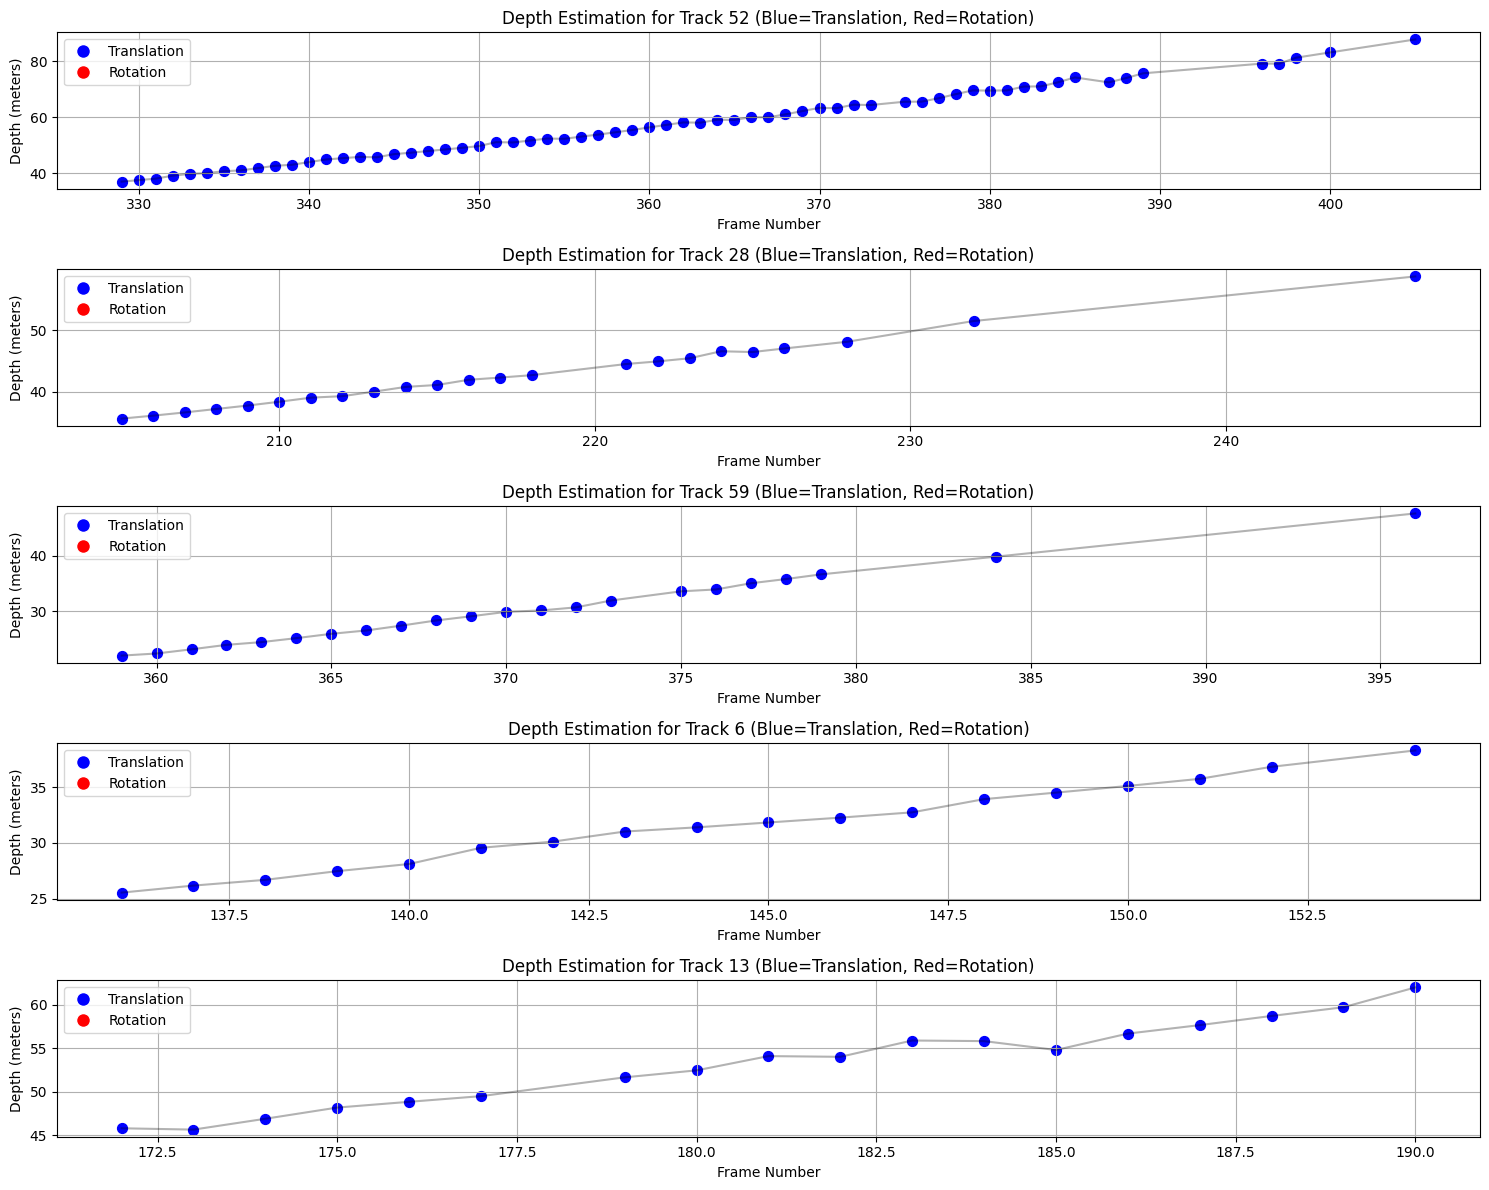

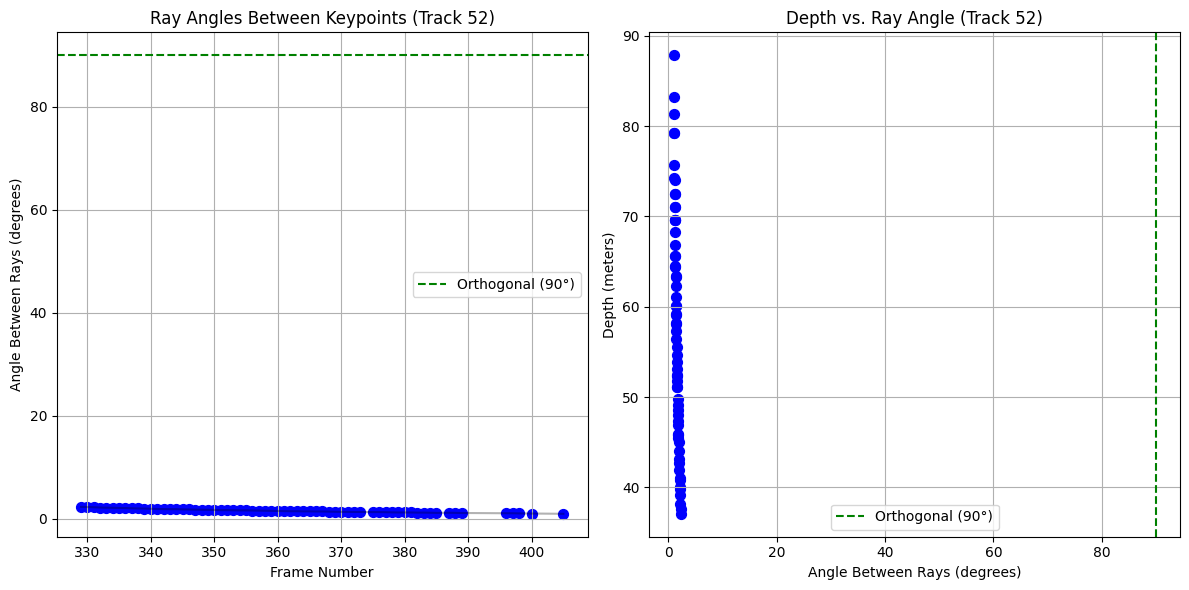

In [9]:
import math
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import os

print("--- Starting Depth Calculation and Movement Analysis ---")

# --- Parameters for Depth Calculation ---
# Average width of a vehicle in meters
AVERAGE_VEHICLE_WIDTH = 1.5  # meters

# Use the existing camera parameters
focal_length = final_camera_parameters['focal_length_x']  # Using the x-axis focal length

# Camera intrinsic matrix K
K = np.array([
    [final_camera_parameters['focal_length_x'], 0, final_camera_parameters['principal_point_x']],
    [0, final_camera_parameters['focal_length_y'], final_camera_parameters['principal_point_y']],
    [0, 0, 1]
])
K_inv = np.linalg.inv(K)  # Inverse of camera matrix for back-projection

# --- Initialize Depth History ---
depth_history = {}  # {track_id: {frame_idx: {'depth': depth_value, 'angle': angle_value, 'movement_type': type}}}

# --- Load Keypoint History ---
print("Loading keypoint history...")
try:
    with open(output_keypoint_history_path, 'r') as f:
        keypoint_data = json.load(f)
    # Convert keys back to int
    keypoint_history = {}
    for tid_str, history_list in keypoint_data.items():
        tid = int(tid_str)
        keypoint_history[tid] = {}
        for item in history_list:
            frame_idx = item[0]
            lkp = tuple(item[1]) if item[1] else None
            rkp = tuple(item[2]) if item[2] else None
            keypoint_history[tid][frame_idx] = {'lkp': lkp, 'rkp': rkp}
    print(f"Loaded keypoint history for {len(keypoint_history)} tracks.")
except FileNotFoundError:
    print(f"Error: Keypoint history file not found at {output_keypoint_history_path}")
    raise
except Exception as e:
    print(f"Error loading keypoint history: {e}")
    raise

# --- Process Each Track and Calculate Depth ---
print("\nCalculating depth and analyzing movement for each valid keypoint pair...")
processed_frames_count = 0
valid_depth_count = 0
start_time_depth = time.time()

# Find valid sequences as defined in your visualization code
max_vertical_alignment_diff_pixels = 15
min_horizontal_distance_pixels = 20
max_horizontal_distance_pixels = 150

# Function to back-project a 2D point to a 3D ray
def back_project_to_ray(point_2d):
    # Convert to homogeneous coordinates
    point_homogeneous = np.array([point_2d[0], point_2d[1], 1.0])
    # Back-project using K^-1
    ray = K_inv.dot(point_homogeneous)
    # Normalize the ray
    ray = ray / np.linalg.norm(ray)
    return ray

# Function to check orthogonality between two rays
def check_ray_orthogonality(ray1, ray2):
    # Calculate dot product
    dot_product = np.dot(ray1, ray2)
    # Calculate angle between rays in degrees
    angle = math.degrees(math.acos(np.clip(dot_product, -1.0, 1.0)))
    # Check if rays are approximately orthogonal (90 degrees ± tolerance)
    orthogonality_tolerance = 15  # degrees
    is_orthogonal = abs(angle - 90) <= orthogonality_tolerance
    return is_orthogonal, angle

print("Finding valid sequences and analyzing movement...")
for track_id, frame_data in keypoint_history.items():
    depth_history[track_id] = {}
    sorted_frame_indices = sorted(frame_data.keys())
    
    for frame_idx in sorted_frame_indices:
        processed_frames_count += 1


        
        if processed_frames_count % 100 == 0:
            elapsed = time.time() - start_time_depth
            fps = processed_frames_count / elapsed if elapsed > 0 else 0
            print(f"  Processed {processed_frames_count} frames... ({fps:.2f} frames/sec)")
        
        kps = frame_data[frame_idx]
        left_kp = kps['lkp']
        right_kp = kps['rkp']
                # very early in the loop, once per frame is enough

        # Skip if either keypoint is missing
        if left_kp is None or right_kp is None:
            continue

        # quick and dirty: use the 2‑D box width in pixels
        # bbox_width_px = abs(right_kp[0] - left_kp[0]) * 1.3  # 1.3 is just a guess
        # pseudo_width  = (bbox_width_px / focal_length) * depth  # crude scale
        # print(f"[W] t{track_id} f{frame_idx}: w_est={pseudo_width:4.2f}m")
        if frame_idx % 30 == 0:
            print(f"[DIST] t{track_id} f{frame_idx}: u_L={left_kp[0]:4d}, u_R={right_kp[0]:4d}")
        # Calculate differences
        vertical_alignment_diff = abs(left_kp[1] - right_kp[1])  # Y difference
        horizontal_distance = abs(left_kp[0] - right_kp[0])      # X difference
        
        # Check if this is a valid keypoint pair
        if (vertical_alignment_diff <= max_vertical_alignment_diff_pixels and 
            min_horizontal_distance_pixels <= horizontal_distance <= max_horizontal_distance_pixels):

            # ── Back‑project keypoints to 3‑D rays ──────────────────────────
            left_ray  = back_project_to_ray(left_kp)
            right_ray = back_project_to_ray(right_kp)
            
            # ── True 3‑D angle between those rays (dot‑product) ────────────
            cos_theta      = np.clip(np.dot(left_ray, right_ray), -1.0, 1.0)
            angle_radians  = math.acos(cos_theta)
            if angle_radians < 1e-6:          # rays are almost identical → unreliable
                continue
            
            angle_degrees  = math.degrees(angle_radians)
            
            # ── Depth from that angle ───────────────────────────────────────
            depth = AVERAGE_VEHICLE_WIDTH / (2 * math.tan(angle_radians / 2))

            # right after you compute angle_degrees and depth
            # if angle_degrees < 5:          # tiny angles are the touchy ones
            #     print(f"[GEO] t{track_id:3d} f{frame_idx:4d}  "
            #           f"angle={angle_degrees:5.2f}°  horizpx={horizontal_distance:4d}  "
            #           f"depth={depth:7.2f}m  Kfx={K[0,0]:.1f}")
            
            # ── Orthogonality test for movement label (kept as you had it) ─
            orthogonality_tol = 15  # degrees
            is_orthogonal = abs(angle_degrees - 90) <= orthogonality_tol
            movement_type = "rotation" if is_orthogonal else "translation"
            
            # ── Store results ───────────────────────────────────────────────
            depth_history[track_id][frame_idx] = {
                'depth'          : depth,
                'angle'          : angle_degrees,   # the dot‑product angle
                'ray_angle'      : angle_degrees,      
                'pixel_distance' : horizontal_distance,
                'left_kp'        : left_kp,
                'right_kp'       : right_kp,
                'movement_type'  : movement_type,
                'left_ray'       : left_ray.tolist(),
                'right_ray'      : right_ray.tolist()
            }
            valid_depth_count += 1

end_time_depth = time.time()
total_time_depth = end_time_depth - start_time_depth
avg_fps_depth = processed_frames_count / total_time_depth if total_time_depth > 0 else 0

print(f"\n--- Finished Depth Calculation and Movement Analysis ---")
print(f"Processed {processed_frames_count} frames in {total_time_depth:.2f} seconds (Avg: {avg_fps_depth:.2f} frames/sec).")
print(f"Successfully calculated depth and analyzed movement for {valid_depth_count} frames with valid keypoint pairs.")

# --- Count movement types ---
translation_count = 0
rotation_count = 0
for track_id, frames in depth_history.items():
    for frame_idx, data in frames.items():
        if data['movement_type'] == 'translation':
            translation_count += 1
        else:
            rotation_count += 1

print(f"Movement analysis results: {translation_count} translations, {rotation_count} rotations")

# --- Save Depth History ---
output_depth_history_path = './output_data/depth_history.json'
print(f"Saving depth history to {output_depth_history_path}...")
try:
    # Convert to serializable format
    serializable_depth_history = {}
    for tid, frames in depth_history.items():
        if frames:  # Only include tracks with valid depth calculations
            serializable_depth_history[str(tid)] = {}
            for f_idx, data in frames.items():
                serializable_depth_history[str(tid)][str(f_idx)] = {
                    'depth': float(data['depth']),
                    'angle': float(data['angle']),
                    'pixel_distance': float(data['pixel_distance']),
                    'left_kp': [int(data['left_kp'][0]), int(data['left_kp'][1])],
                    'right_kp': [int(data['right_kp'][0]), int(data['right_kp'][1])],
                    'ray_angle': float(data['ray_angle']),
                    'movement_type': data['movement_type']
                    # Not storing rays in JSON as they're not needed for visualization
                }
    
    with open(output_depth_history_path, 'w') as f:
        json.dump(serializable_depth_history, f, indent=4)
    print("Depth history saved successfully.")
except Exception as e:
    print(f"Error saving depth history: {e}")

# --- Visualize Depth Results and Movement Analysis for Sample Tracks ---
# Choose tracks with good depth data
sample_tracks = []
for track_id, frames in depth_history.items():
    if len(frames) >= 5:  # At least 5 frames with valid depth
        sample_tracks.append((track_id, len(frames)))

if sample_tracks:
    # Sort by number of frames with depth data
    sample_tracks.sort(key=lambda x: x[1], reverse=True)
    
    # Take top 5 tracks
    tracks_to_visualize = sample_tracks[:5]
    
    plt.figure(figsize=(15, 12))
    
    for i, (track_id, num_frames) in enumerate(tracks_to_visualize):
        # Get frame indices and depths
        frames = sorted(depth_history[track_id].keys())
        depths = [depth_history[track_id][f]['depth'] for f in frames]
        
        # Color points by movement type
        colors = []
        for f in frames:
            if depth_history[track_id][f]['movement_type'] == 'translation':
                colors.append('blue')
            else:
                colors.append('red')
        
        # Plot depth over frames
        plt.subplot(len(tracks_to_visualize), 1, i+1)
        
        # Create scatter plot with colors based on movement type
        for j, frame in enumerate(frames):
            plt.scatter(frame, depths[j], color=colors[j], s=50)
        
        # Connect points with lines
        plt.plot(frames, depths, 'k-', alpha=0.3)
        
        plt.title(f'Depth Estimation for Track {track_id} (Blue=Translation, Red=Rotation)')
        plt.xlabel('Frame Number')
        plt.ylabel('Depth (meters)')
        plt.grid(True)
        
        # Add legend
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Translation'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Rotation')
        ]
        plt.legend(handles=legend_elements)
    
    plt.tight_layout()
    plt.show()
    
    # Also create a visualization of ray angles for one track
    if tracks_to_visualize:
        best_track_id = tracks_to_visualize[0][0]
        frames = sorted(depth_history[best_track_id].keys())
        
        plt.figure(figsize=(12, 6))
        
        # Plot 1: Ray angles vs. frame
        plt.subplot(1, 2, 1)
        ray_angles = [depth_history[best_track_id][f]['ray_angle'] for f in frames]
        
        # Color points by movement type
        colors = []
        for f in frames:
            if depth_history[best_track_id][f]['movement_type'] == 'translation':
                colors.append('blue')
            else:
                colors.append('red')
        
        # Create scatter plot with colors based on movement type
        for j, frame in enumerate(frames):
            plt.scatter(frame, ray_angles[j], color=colors[j], s=50)
            
        # Connect points with lines
        plt.plot(frames, ray_angles, 'k-', alpha=0.3)
        
        # Add horizontal line at 90 degrees
        plt.axhline(y=90, color='green', linestyle='--', label='Orthogonal (90°)')
        
        plt.title(f'Ray Angles Between Keypoints (Track {best_track_id})')
        plt.xlabel('Frame Number')
        plt.ylabel('Angle Between Rays (degrees)')
        plt.grid(True)
        plt.legend()
        
        # Plot 2: Depth vs. ray angle
        plt.subplot(1, 2, 2)
        depths = [depth_history[best_track_id][f]['depth'] for f in frames]
        
        # Create scatter plot with colors based on movement type
        for j in range(len(frames)):
            plt.scatter(ray_angles[j], depths[j], color=colors[j], s=50)
        
        plt.title(f'Depth vs. Ray Angle (Track {best_track_id})')
        plt.xlabel('Angle Between Rays (degrees)')
        plt.ylabel('Depth (meters)')
        plt.grid(True)
        
        # Add vertical line at 90 degrees
        plt.axvline(x=90, color='green', linestyle='--', label='Orthogonal (90°)')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
else:
    print("No tracks with sufficient depth data for visualization.")

--- Starting Improved Depth and Movement Visualization on Video ---
Loading depth history from ./output_data/depth_history.json...
Loaded depth history for 12 tracks.
Loading track history from ./output_data/track_history.json...
Loaded track history for 51 tracks.
Organizing data by frame...
Processing frames from 125 to 500
Processing video and creating visualization...
Processed 50 frames... (66.40 fps)
Processed 100 frames... (79.77 fps)
Processed 150 frames... (86.53 fps)
Processed 200 frames... (90.95 fps)
Processed 250 frames... (92.16 fps)
Processed 300 frames... (93.95 fps)
Processed 350 frames... (95.42 fps)

--- Finished Depth and Movement Visualization ---
Processed 376 frames in 3.93 seconds.
Output video saved to: ./output_videos/depth_analysis_visualization.mp4

Creating improved ray visualization...
Processed 50 frames... (68.42 fps)
Processed 100 frames... (82.13 fps)
Processed 150 frames... (87.98 fps)
Processed 200 frames... (92.33 fps)
Processed 250 frames... (93.87

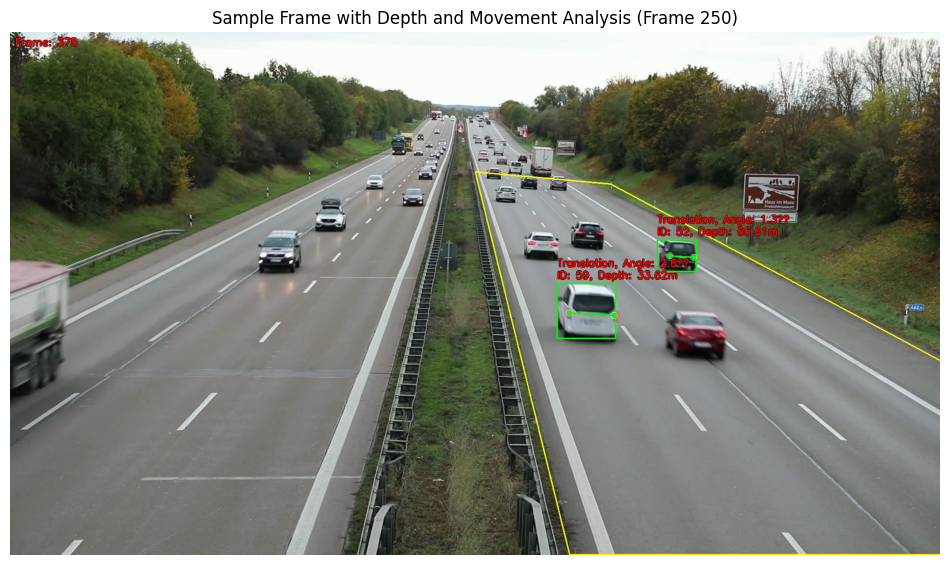

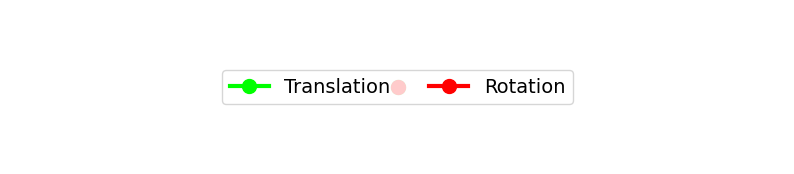

In [18]:
# --- Improved Visualization of Depth and Movement Analysis on Video ---
import cv2
import json
import numpy as np
import os
import time
from collections import defaultdict

print("--- Starting Improved Depth and Movement Visualization on Video ---")

# --- Parameters ---
output_video_path = './output_videos/depth_analysis_visualization.mp4'
input_video_path = video_path  # Using the same input video path defined earlier
depth_history_path = './output_data/depth_history.json'

# Time range to process (matching your detection and tracking)
start_time = 5  # in seconds
end_time = 20   # in seconds

# Visualization parameters
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.7  # Increased font size
thickness = 2     # Increased thickness
line_thickness = 2

# Colors (BGR format)
translation_color = (0, 255, 0)   # Green
rotation_color = (0, 0, 255)      # Red
bbox_color = (255, 255, 0)        # Cyan
text_color = (0, 0, 255)          # Red (for better visibility)
ray_color = (255, 165, 0)         # Orange

# --- Load Depth History ---
print(f"Loading depth history from {depth_history_path}...")
try:
    with open(depth_history_path, 'r') as f:
        depth_data = json.load(f)
    
    # Convert to more usable format
    depth_history = {}
    for track_id_str, frames in depth_data.items():
        track_id = int(track_id_str)
        depth_history[track_id] = {}
        for frame_idx_str, data in frames.items():
            frame_idx = int(frame_idx_str)
            depth_history[track_id][frame_idx] = data
    
    print(f"Loaded depth history for {len(depth_history)} tracks.")
except FileNotFoundError:
    print(f"Error: Depth history file not found at {depth_history_path}")
    raise
except Exception as e:
    print(f"Error loading depth history: {e}")
    raise

# --- Load Track History for Bounding Boxes ---
print(f"Loading track history from {output_track_history_path}...")
try:
    with open(output_track_history_path, 'r') as f:
        track_data = json.load(f)
    
    # Convert to more usable format
    track_history = {}
    for track_id_str, history in track_data.items():
        track_id = int(track_id_str)
        track_history[track_id] = {}
        for item in history:
            frame_idx = item[0]
            bbox = tuple(item[1])
            track_history[track_id][frame_idx] = bbox
    
    print(f"Loaded track history for {len(track_history)} tracks.")
except FileNotFoundError:
    print(f"Error: Track history file not found at {output_track_history_path}")
    raise
except Exception as e:
    print(f"Error loading track history: {e}")
    raise

# --- Organize Data by Frame ---
print("Organizing data by frame...")
frame_data = defaultdict(list)
for track_id, frames in depth_history.items():
    for frame_idx, data in frames.items():
        if track_id in track_history and frame_idx in track_history[track_id]:
            bbox = track_history[track_id][frame_idx]
            frame_data[frame_idx].append({
                'track_id': track_id,
                'bbox': bbox,
                'depth': data['depth'],
                'movement_type': data['movement_type'],
                'left_kp': data['left_kp'],
                'right_kp': data['right_kp'],
                'ray_angle': data.get('ray_angle', 0)
            })

# --- Process Video ---
cap = cv2.VideoCapture(input_video_path)
if not cap.isOpened():
    print(f"Error: Could not open video file {input_video_path}")
    raise FileNotFoundError(f"Video file not found or cannot be opened: {input_video_path}")

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Calculate start and end frames
start_frame = int(start_time * fps)
end_frame = int(end_time * fps)
print(f"Processing frames from {start_frame} to {end_frame}")

# Create output video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Process frames
print(f"Processing video and creating visualization...")
frame_count = 0
processed_count = 0
start_time_processing = time.time()

# Function to add a black outline to text for better visibility
def draw_text_with_outline(img, text, position, font, scale, color, thickness):
    # Draw black outline
    cv2.putText(img, text, position, font, scale, (0, 0, 0), thickness + 2)
    # Draw colored text
    cv2.putText(img, text, position, font, scale, color, thickness)

# Seek to start frame
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
frame_count = start_frame

while frame_count <= end_frame:
    ret, frame = cap.read()
    if not ret:
        break
    
    processed_count += 1
    # Draw ROI
    cv2.polylines(frame, [roi_polygon], True, (0, 255, 255), 2) # Yellow ROI
    if frame_count in frame_data:
        for item in frame_data[frame_count]:
            track_id = item['track_id']
            bbox = item['bbox']
            depth = item['depth']
            movement_type = item['movement_type']
            left_kp = item['left_kp']
            right_kp = item['right_kp']
            ray_angle = item['ray_angle']
            
            # Determine color based on movement type
            color = translation_color if movement_type == 'translation' else rotation_color
            

            # Draw bounding box
            x1, y1, x2, y2 = map(int, bbox)
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, line_thickness)
            
            # Draw keypoints
            if left_kp:
                cv2.circle(frame, (int(left_kp[0]), int(left_kp[1])), 5, color, -1)
                # Add white outline for better visibility
                cv2.circle(frame, (int(left_kp[0]), int(left_kp[1])), 7, (255, 255, 255), 1)
            if right_kp:
                cv2.circle(frame, (int(right_kp[0]), int(right_kp[1])), 5, color, -1)
                # Add white outline for better visibility
                cv2.circle(frame, (int(right_kp[0]), int(right_kp[1])), 7, (255, 255, 255), 1)
            
            # Draw line between keypoints
            if left_kp and right_kp:
                cv2.line(frame, 
                         (int(left_kp[0]), int(left_kp[1])), 
                         (int(right_kp[0]), int(right_kp[1])), 
                         color, 2)
            
            # Display track ID and depth with outline for better visibility
            text = f"ID: {track_id}, Depth: {depth:.2f}m"
            draw_text_with_outline(frame, text, (x1, y1 - 10), font, font_scale, text_color, thickness)
            
            # Display movement type and ray angle
            movement_text = f"{movement_type.capitalize()}, Angle: {ray_angle:.1f}°"
            draw_text_with_outline(frame, movement_text, (x1, y1 - 35), font, font_scale, text_color, thickness)
    
    # Add frame counter with outline
    draw_text_with_outline(frame, f"Frame: {frame_count}", (10, 30), font, font_scale, text_color, thickness)
    
    # Write frame to output video
    out.write(frame)
    
    # Progress update
    if processed_count % 50 == 0:
        elapsed = time.time() - start_time_processing
        fps_processing = processed_count / elapsed if elapsed > 0 else 0
        print(f"Processed {processed_count} frames... ({fps_processing:.2f} fps)")
    
    frame_count += 1

# Cleanup
cap.release()
out.release()

print(f"\n--- Finished Depth and Movement Visualization ---")
print(f"Processed {processed_count} frames in {time.time() - start_time_processing:.2f} seconds.")
print(f"Output video saved to: {output_video_path}")

# --- Create a Better Ray Visualization ---
output_rays_video_path = './output_videos/depth_analysis_with_rays.mp4'
print(f"\nCreating improved ray visualization...")

# Function to draw the back-projected rays with better visualization
def draw_improved_rays(frame, left_kp, right_kp, movement_type, ray_angle):
    # Determine color based on movement type
    color = translation_color if movement_type == 'translation' else rotation_color
    
    # Draw keypoints with white outline for better visibility
    cv2.circle(frame, (int(left_kp[0]), int(left_kp[1])), 5, color, -1)
    cv2.circle(frame, (int(left_kp[0]), int(left_kp[1])), 7, (255, 255, 255), 1)
    cv2.circle(frame, (int(right_kp[0]), int(right_kp[1])), 5, color, -1)
    cv2.circle(frame, (int(right_kp[0]), int(right_kp[1])), 7, (255, 255, 255), 1)
    
    # Draw line between keypoints
    cv2.line(frame, 
             (int(left_kp[0]), int(left_kp[1])), 
             (int(right_kp[0]), int(right_kp[1])), 
             color, 2)
    
    # Calculate midpoint between keypoints
    mid_x = (left_kp[0] + right_kp[0]) // 2
    mid_y = (left_kp[1] + right_kp[1]) // 2
    
    # Draw an arc to represent the angle between rays
    radius = 50  # Radius of the arc
    start_angle = 0
    end_angle = ray_angle if ray_angle <= 180 else ray_angle - 360
    
    # Convert angles to the format expected by ellipse (which uses 0-360 degrees)
    start_angle_cv = int(start_angle * 10)  # OpenCV uses 0.1 degree units
    end_angle_cv = int(end_angle * 10)
    
    # Draw the arc
    cv2.ellipse(frame, (int(mid_x), int(mid_y)), (radius, radius), 
                0, start_angle_cv, end_angle_cv, color, 2)
    
    # Display the angle
    angle_text = f"Ray Angle: {ray_angle:.1f}°"
    draw_text_with_outline(frame, angle_text, (mid_x - 70, mid_y - 60), 
                          font, font_scale, text_color, thickness)
    
    # Display the movement type
    movement_text = f"Movement: {movement_type.capitalize()}"
    draw_text_with_outline(frame, movement_text, (mid_x - 70, mid_y - 30), 
                          font, font_scale, text_color, thickness)
    
    # Add a reference line for 90 degrees if close to orthogonal
    if abs(ray_angle - 90) < 20:
        # Draw a 90-degree reference line
        cv2.line(frame, (mid_x, mid_y), (mid_x + radius, mid_y), (255, 255, 255), 1)
        cv2.line(frame, (mid_x, mid_y), (mid_x, mid_y - radius), (255, 255, 255), 1)
        # Add text indicating 90 degrees
        draw_text_with_outline(frame, "90°", (mid_x + radius + 5, mid_y), 
                              font, 0.5, (255, 255, 255), 1)
    
    return frame

# Process video again with improved ray visualization
cap = cv2.VideoCapture(input_video_path)
out_rays = cv2.VideoWriter(output_rays_video_path, fourcc, fps, (width, height))

frame_count = start_frame
processed_count = 0
start_time_processing = time.time()

# Seek to start frame
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

while frame_count <= end_frame:
    ret, frame = cap.read()
    if not ret:
        break
    
    processed_count += 1
    
    if frame_count in frame_data:
        for item in frame_data[frame_count]:
            left_kp = item['left_kp']
            right_kp = item['right_kp']
            movement_type = item['movement_type']
            ray_angle = item['ray_angle']
            
            if left_kp and right_kp:
                # Draw the improved ray visualization
                frame = draw_improved_rays(frame, left_kp, right_kp, movement_type, ray_angle)
    
    # Add frame counter with outline
    draw_text_with_outline(frame, f"Frame: {frame_count}", (10, 30), font, font_scale, text_color, thickness)
    
    # Add explanation text
    explanation = "Angles close to 90° indicate rotation, others indicate translation"
    draw_text_with_outline(frame, explanation, (width // 2 - 250, height - 30), 
                          font, 0.6, (255, 255, 255), 1)
    
    # Write frame to output video
    out_rays.write(frame)
    
    # Progress update
    if processed_count % 50 == 0:
        elapsed = time.time() - start_time_processing
        fps_processing = processed_count / elapsed if elapsed > 0 else 0
        print(f"Processed {processed_count} frames... ({fps_processing:.2f} fps)")
    
    frame_count += 1

# Cleanup
cap.release()
out_rays.release()

print(f"\n--- Finished Improved Ray Visualization ---")
print(f"Output video with rays saved to: {output_rays_video_path}")

# Display a sample frame with annotations
cap = cv2.VideoCapture(output_video_path)
# Skip to a frame where we know there's data
sample_frames = [frame_idx for frame_idx in frame_data.keys() 
                if start_frame <= frame_idx <= end_frame]
if sample_frames:
    sample_frame_idx = sample_frames[len(sample_frames) // 2]
    cap.set(cv2.CAP_PROP_POS_FRAMES, sample_frame_idx)
    ret, sample_frame = cap.read()
     
    if ret:
        # Convert BGR to RGB for display
        sample_frame_rgb = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB)
        
        # Display the sample frame
        plt.figure(figsize=(12, 8))
        plt.imshow(sample_frame_rgb)
        plt.title(f"Sample Frame with Depth and Movement Analysis (Frame {sample_frame_idx})")
        plt.axis('off')
        plt.show()
        
        # Also display a legend
        plt.figure(figsize=(10, 2))
        plt.plot([0], [0], 'o-', color=tuple(c/255 for c in translation_color[::-1]), 
                 label='Translation', linewidth=3, markersize=10)
        plt.plot([0], [0], 'o-', color=tuple(c/255 for c in rotation_color[::-1]), 
                 label='Rotation', linewidth=3, markersize=10)
        plt.legend(loc='center', ncol=2, fontsize=14)
        plt.axis('off')
        plt.show()

cap.release()

Kinematics data saved to ./output_data/kinematics_data.json
Top tracks by number of frames: [('52', 64), ('28', 23), ('59', 22), ('6', 18), ('13', 18), ('60', 16), ('23', 15), ('37', 13), ('54', 4)]


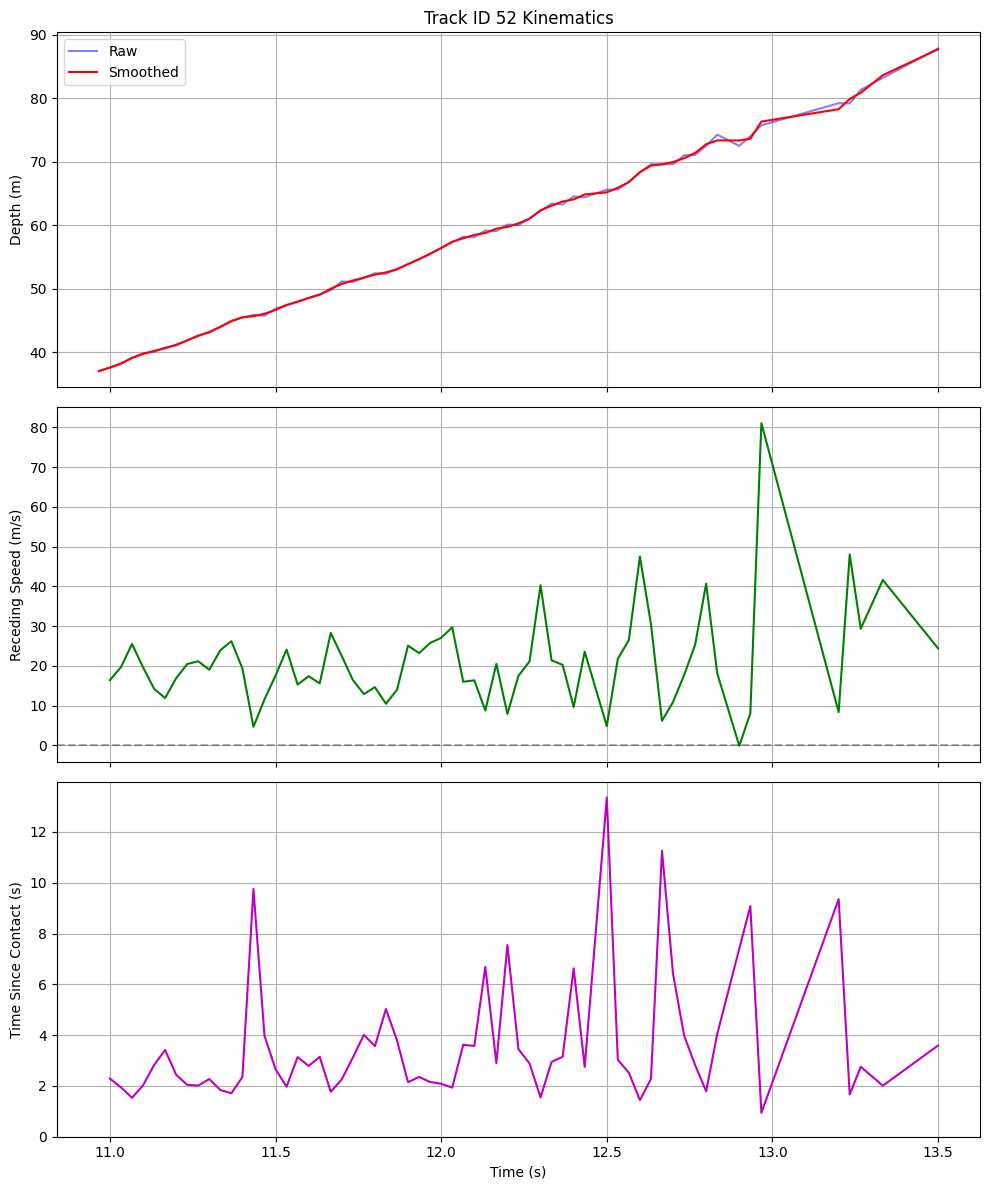

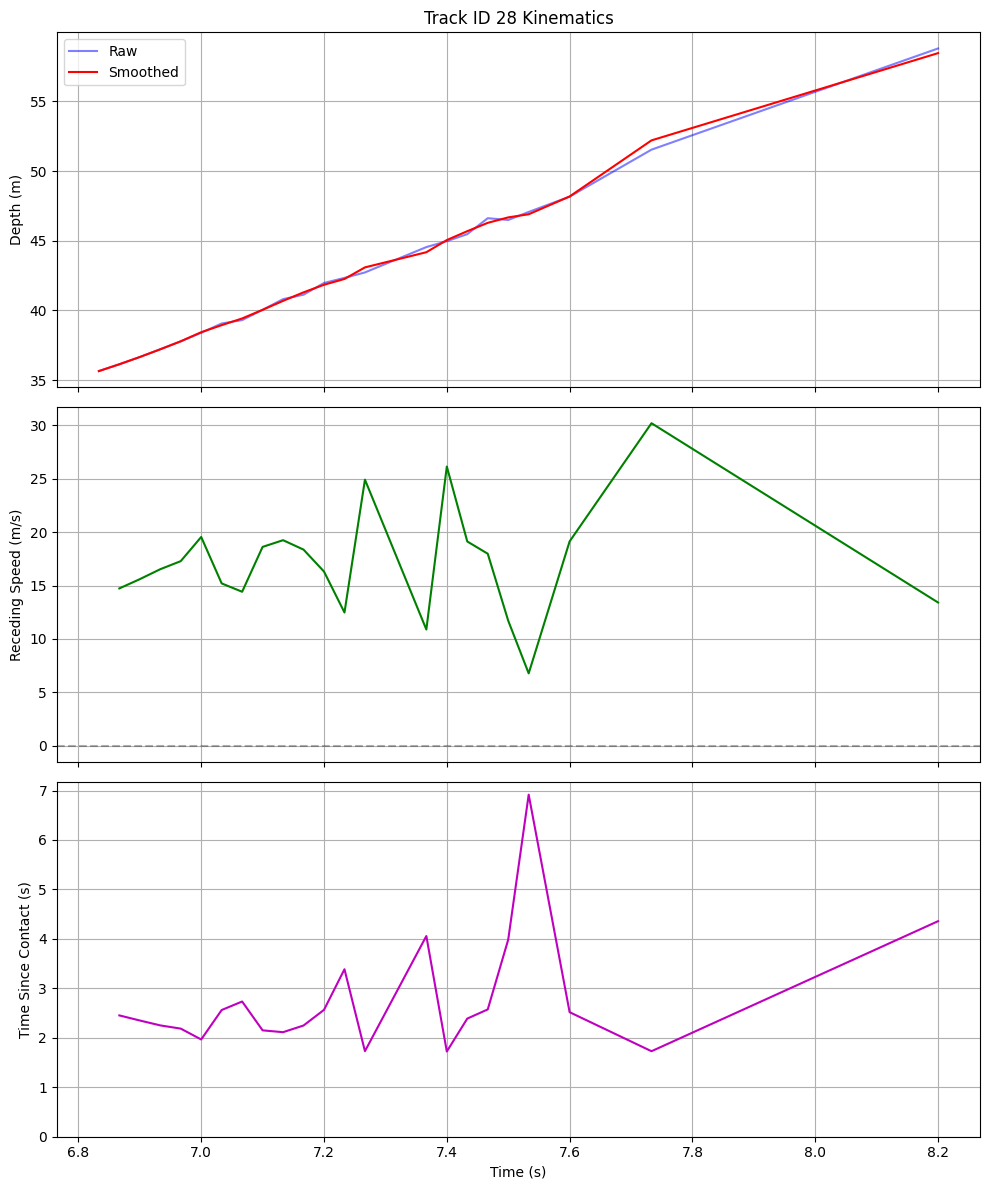

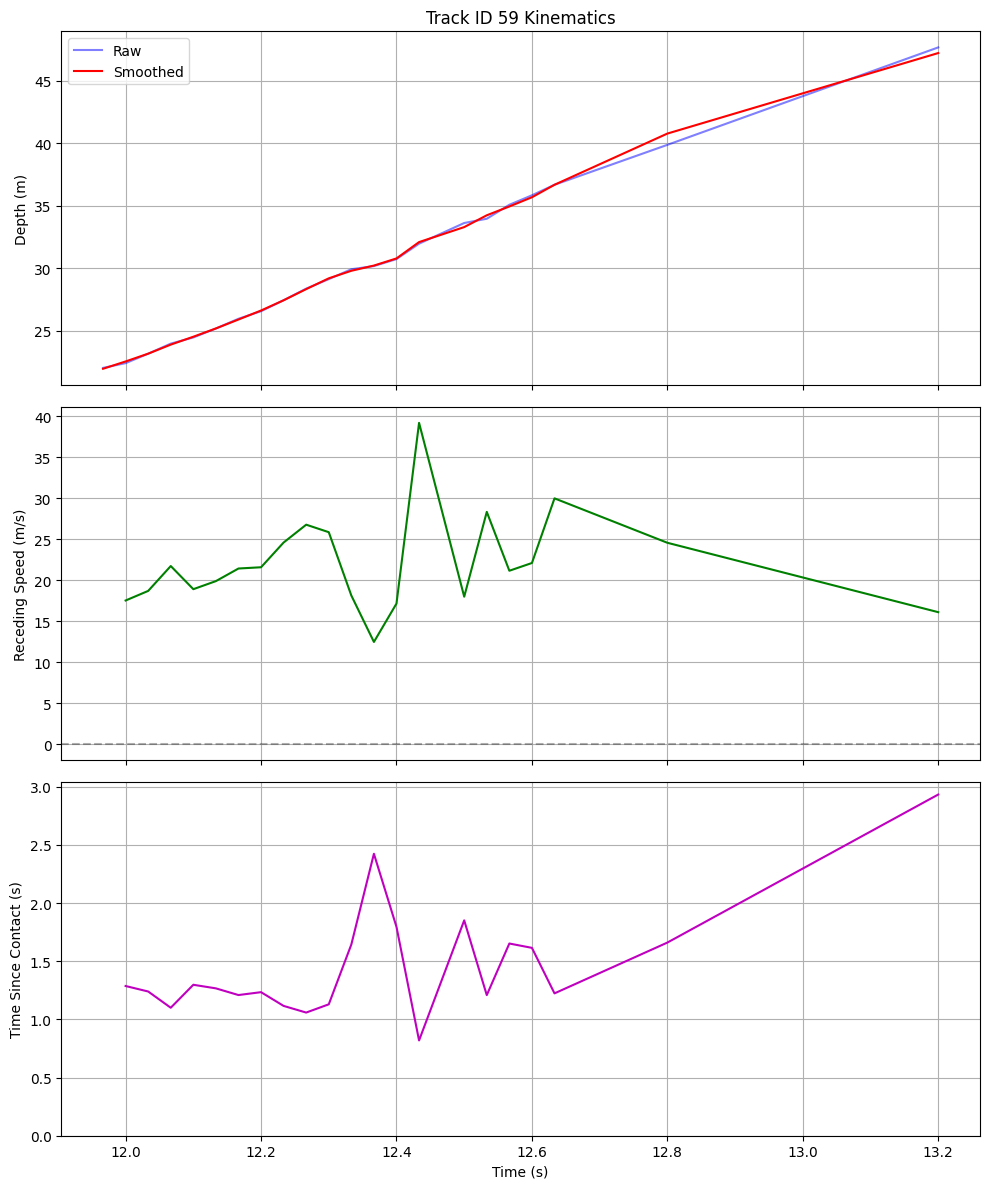

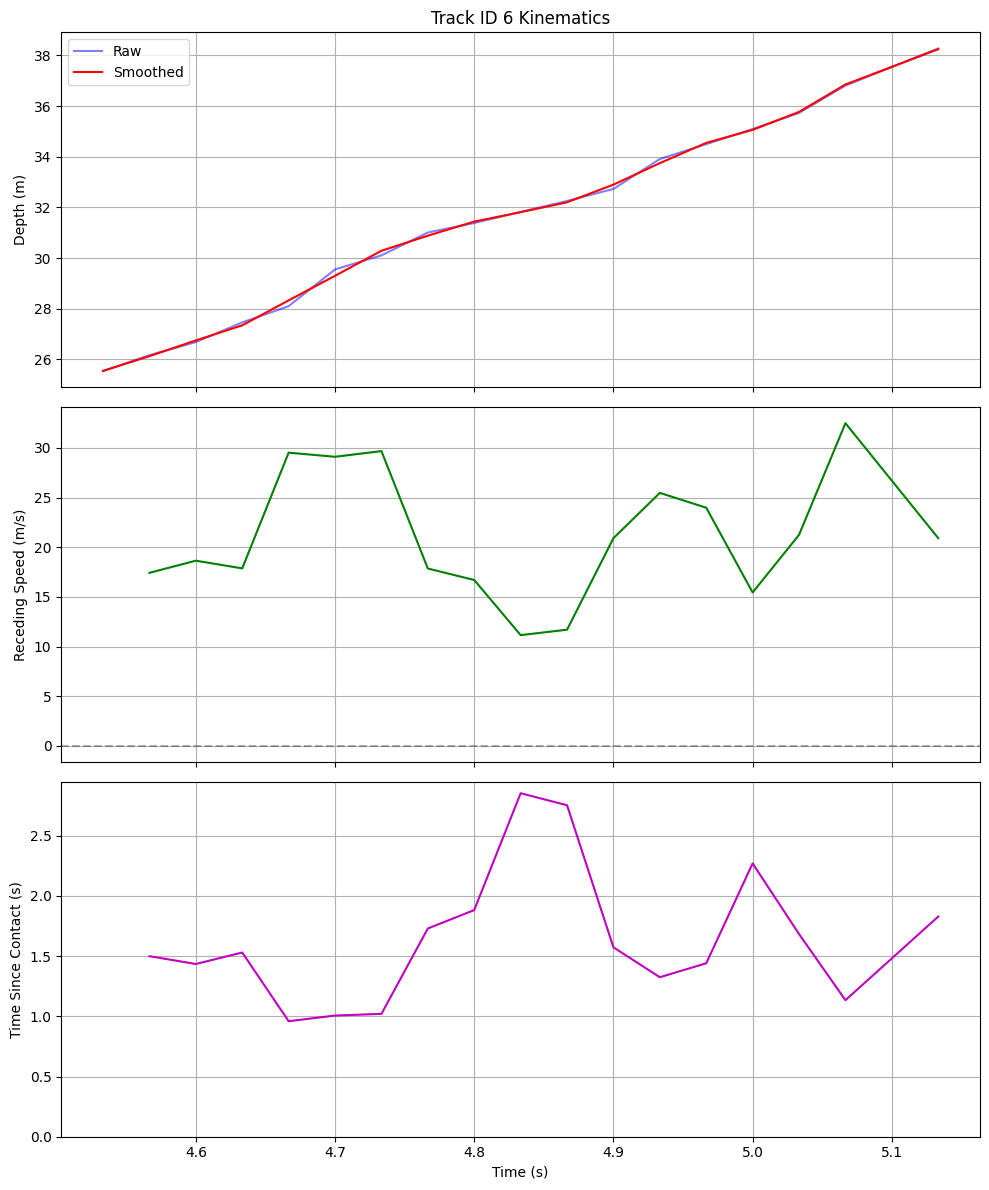

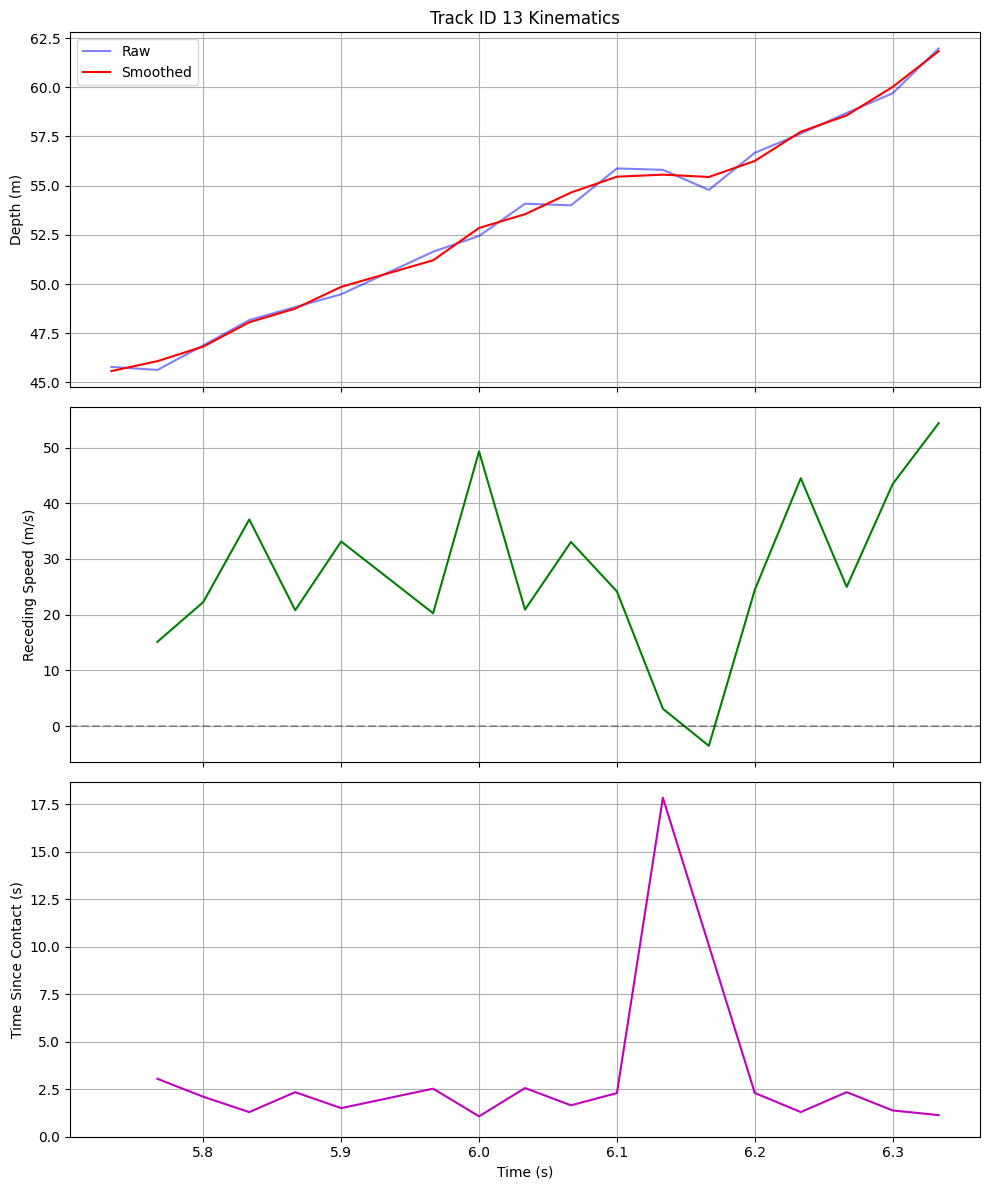

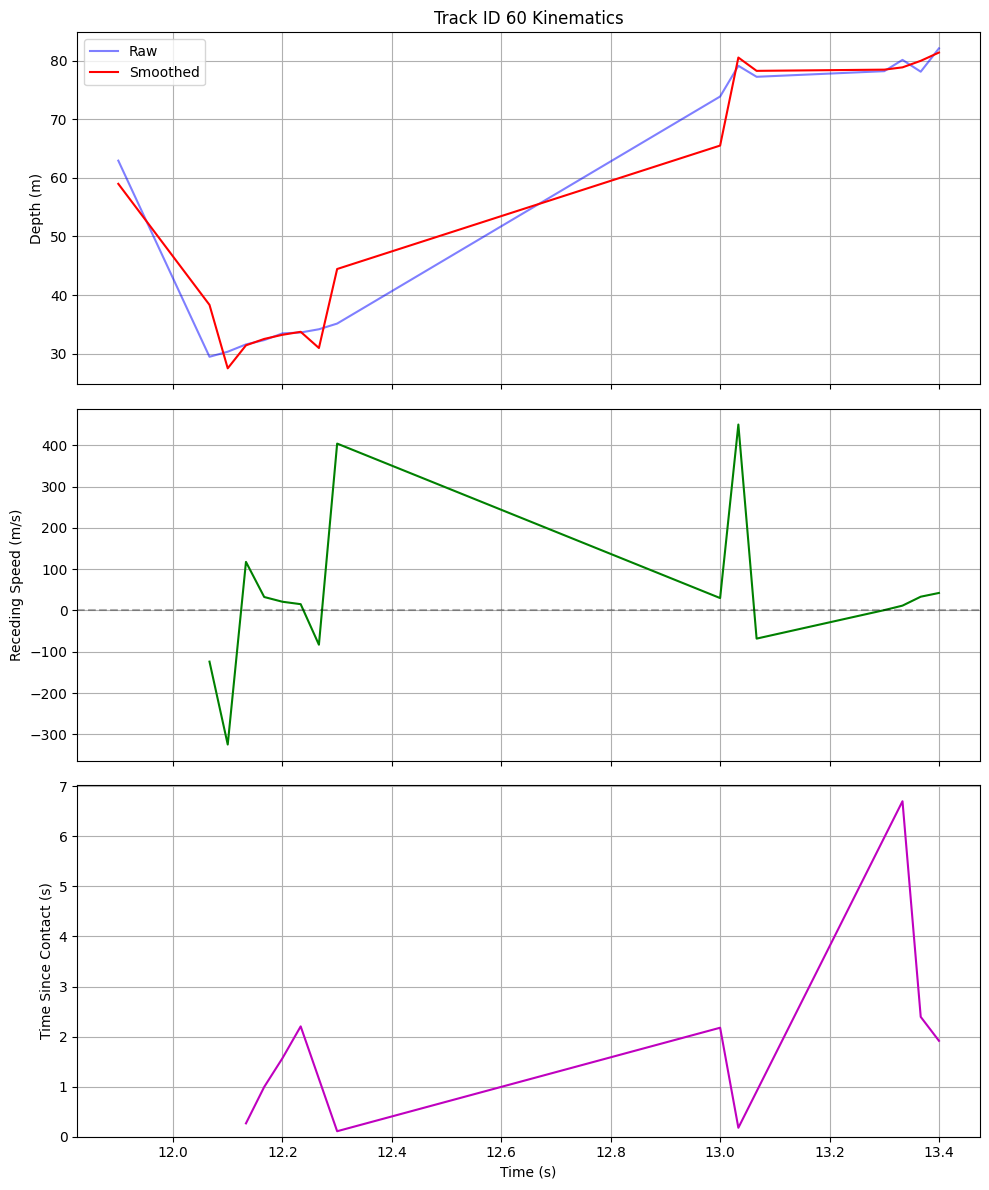

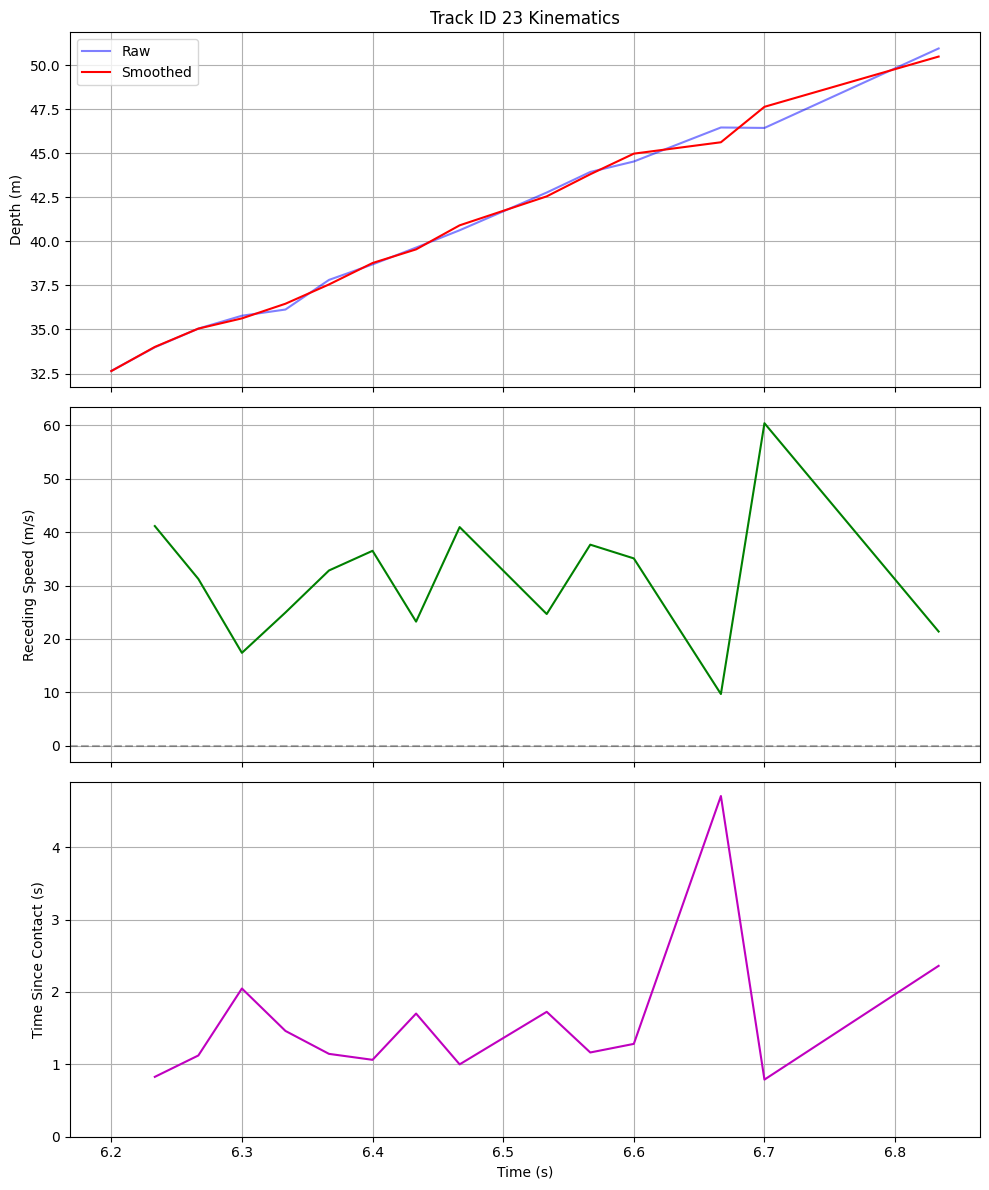

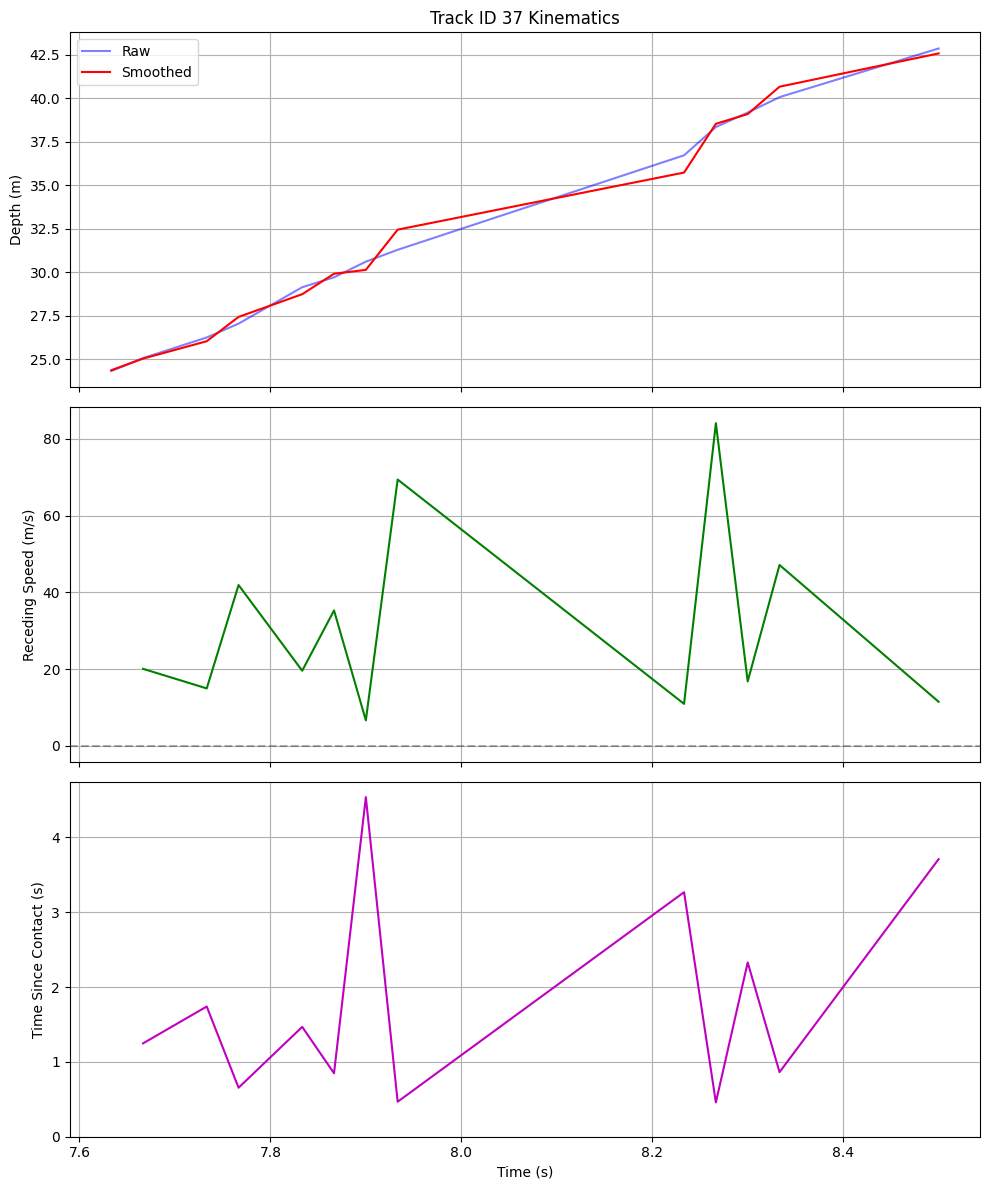

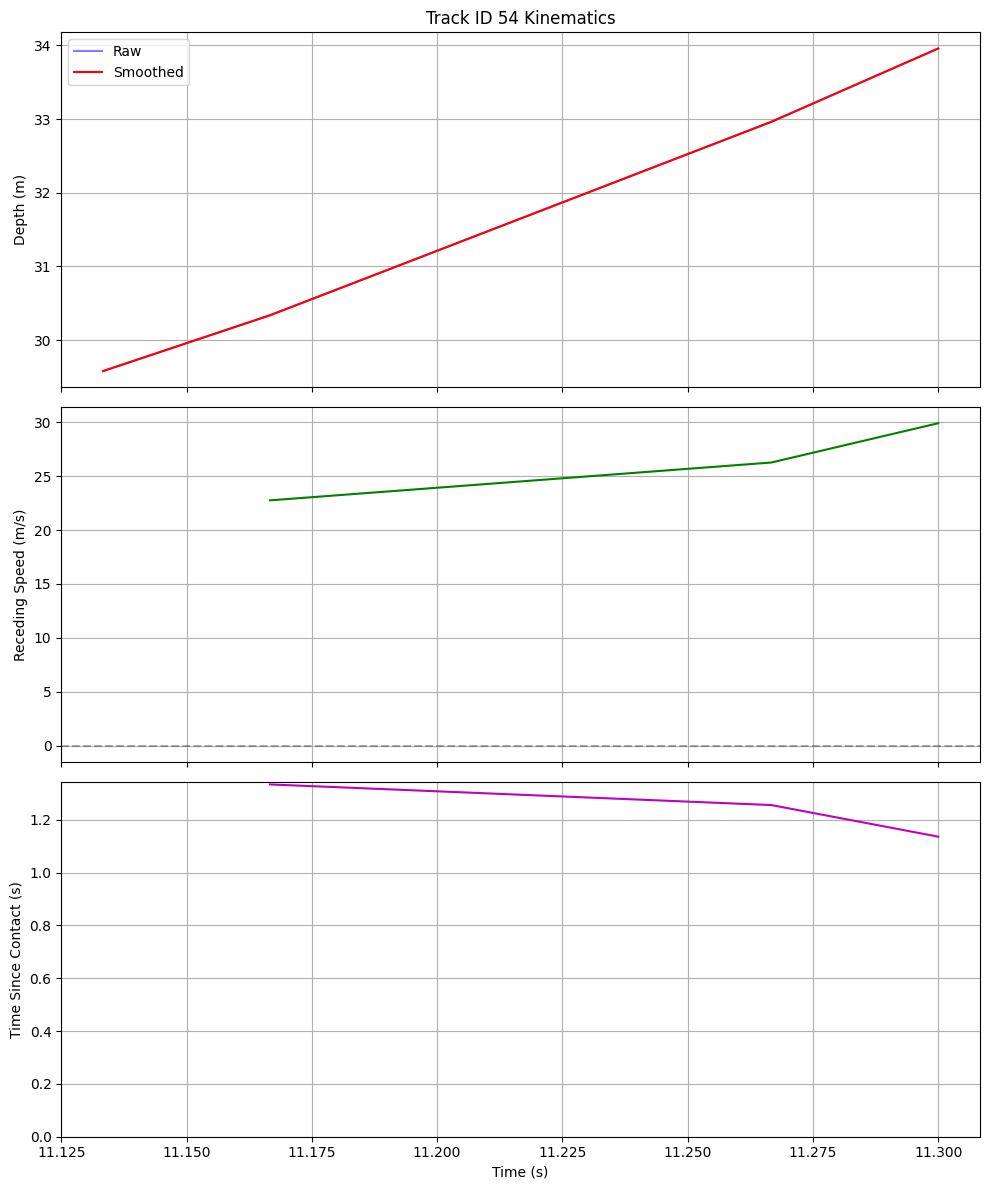

In [10]:
# Per-track kinematics calculation for receding vehicles
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Load the depth history data
with open('./output_data/depth_history.json', 'r') as f:
    depth_history = json.load(f)

# Create a dictionary to store kinematics data
kinematics_data = {}

# Calculate kinematics for each track
for track_id, track_data in depth_history.items():
    # Extract frame indices and depths, ensuring they're sorted by frame
    frames = []
    depths = []
    for frame_idx, frame_data in track_data.items():
        # Extract depth from the nested dictionary
        depth = frame_data["depth"]
        frames.append(int(frame_idx))
        depths.append(float(depth))
    
    # Sort by frame index
    sorted_data = sorted(zip(frames, depths), key=lambda x: x[0])
    frames = [item[0] for item in sorted_data]
    depths = [item[1] for item in sorted_data]
    
    # Skip tracks with too few points
    if len(frames) < 3:
        continue
    
    # Calculate time in seconds (assuming 30 fps, adjust if different)
    fps = 30.0
    times = [frame / fps for frame in frames]
    
    # Apply a low-pass filter to smooth the depth data
    if len(depths) >= 5:
        window_length = min(5, len(depths) - (len(depths) % 2 - 1))  # Must be odd and <= length
        if window_length >= 3:
            depths_smoothed = savgol_filter(depths, window_length, 2)
        else:
            depths_smoothed = depths
    else:
        depths_smoothed = depths
    
    # Calculate receding speed (positive when moving away)
    receding_speeds = []
    for i in range(1, len(depths_smoothed)):
        # Calculate velocity as change in depth divided by change in time
        dt = times[i] - times[i-1]
        dz = depths_smoothed[i] - depths_smoothed[i-1]
        # Receding speed is positive when moving away
        receding_speed = dz / dt if dt > 0 else 0
        receding_speeds.append(receding_speed)
    
    # Calculate Time Since Contact (TSC)
    tscs = []
    for i in range(len(receding_speeds)):
        # TSC is depth divided by receding speed
        # Only meaningful if object is receding (receding_speed > 0)
        rs = receding_speeds[i]
        z = depths_smoothed[i+1]  # Current depth
        
        if rs > 0:  # Object is receding
            tsc = z / rs  # How long ago the vehicle would have been at the camera
        else:
            tsc = float('nan')  # Not receding or stationary
        
        tscs.append(tsc)
    
    # Store kinematics data
    kinematics_data[track_id] = {
        'frames': frames,
        'times': times,
        'depths': depths,
        'depths_smoothed': depths_smoothed.tolist() if isinstance(depths_smoothed, np.ndarray) else depths_smoothed,
        'receding_speeds': receding_speeds,
        'time_since_contact': tscs
    }

# Save kinematics data to file
output_kinematics_path = './output_data/kinematics_data.json'
with open(output_kinematics_path, 'w') as f:
    json.dump(kinematics_data, f, indent=4)
print(f"Kinematics data saved to {output_kinematics_path}")

# Plot kinematics for a few tracks (optional)
def plot_track_kinematics(track_id):
    if track_id not in kinematics_data:
        print(f"Track ID {track_id} not found in kinematics data")
        return
    
    data = kinematics_data[track_id]
    
    fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    
    # Plot depth
    axs[0].plot(data['times'], data['depths'], 'b-', alpha=0.5, label='Raw')
    axs[0].plot(data['times'], data['depths_smoothed'], 'r-', label='Smoothed')
    axs[0].set_ylabel('Depth (m)')
    axs[0].set_title(f'Track ID {track_id} Kinematics')
    axs[0].legend()
    axs[0].grid(True)
    
    # Plot receding speed
    speed_times = [data['times'][i+1] for i in range(len(data['receding_speeds']))]
    axs[1].plot(speed_times, data['receding_speeds'], 'g-')
    axs[1].set_ylabel('Receding Speed (m/s)')
    axs[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axs[1].grid(True)
    
    # Plot Time Since Contact
    tsc_times = speed_times
    # Filter out NaN TSCs for plotting
    valid_tscs = [(t, tsc) for t, tsc in zip(tsc_times, data['time_since_contact']) 
                 if not np.isnan(tsc) and tsc < 30]
    
    if valid_tscs:
        valid_times, valid_tsc_values = zip(*valid_tscs)
        axs[2].plot(valid_times, valid_tsc_values, 'm-')
        axs[2].set_ylabel('Time Since Contact (s)')
    else:
        axs[2].text(0.5, 0.5, 'No valid Time Since Contact values', 
                   horizontalalignment='center', verticalalignment='center',
                   transform=axs[2].transAxes)
        axs[2].set_ylabel('Time Since Contact (s)')
    
    axs[2].set_xlabel('Time (s)')
    axs[2].set_ylim(bottom=0)
    axs[2].grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot kinematics for a few tracks with the most data points
track_counts = {track_id: len(data['frames']) for track_id, data in kinematics_data.items()}
top_tracks = sorted(track_counts.items(), key=lambda x: x[1], reverse=True)[:9]
print(f"Top tracks by number of frames: {top_tracks}")

for track_id, _ in top_tracks:
    plot_track_kinematics(track_id)

In [18]:
# Visualization of receding speed and time since contact on video
import cv2
import json
import numpy as np
import os
import time
import random
from collections import defaultdict

# Configuration
input_video_path = './input_videos/cars_road_3.mp4'  # Adjust to your video path
output_video_path = './output_videos/kinematics_visualization.mp4'
os.makedirs(os.path.dirname(output_video_path), exist_ok=True)

# Time range to process - ADJUST THESE TO MATCH YOUR DATA
start_time = 4   # in seconds (to include frame 125)
end_time = 20    # in seconds

# Visualization parameters
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.6
thickness = 2
line_thickness = 2
text_color = (255, 255, 255)  # White text
speed_color = (0, 255, 0)     # Green for speed
tsc_color = (0, 165, 255)     # Orange for TSC


# Load the kinematics data
print("Loading kinematics data...")
with open('./output_data/kinematics_data.json', 'r') as f:
    kinematics_data = json.load(f)

# Print some info about kinematics data
print(f"Loaded kinematics data for {len(kinematics_data)} tracks")
for track_id, data in list(kinematics_data.items())[:2]:  # Print first 2 for debugging
    print(f"Track {track_id}: {len(data['frames'])} frames, {len(data.get('receding_speeds', []))} speeds")
    print(f"Sample frames: {data['frames'][:5]}")
    # Find min and max frames in kinematics data
    all_frames = []
    for track_id, data in kinematics_data.items():
        all_frames.extend(data['frames'])
    if all_frames:
        print(f"Kinematics data frame range: {min(all_frames)} to {max(all_frames)}")

# Load track history
print("\nLoading track history...")
try:
    output_track_history_path = './output_data/track_history.json'
    with open(output_track_history_path, 'r') as f:
        track_history_data = json.load(f)
    
    # Print some info about track history
    print(f"Loaded track history for {len(track_history_data)} tracks")
    for track_id, items in list(track_history_data.items())[:2]:  # Print first 2 for debugging
        print(f"Track {track_id}: {len(items)} frames")
        print(f"Sample frame data: {items[:2]}")
    
    # Find min and max frames in track history
    all_track_frames = []
    for track_id, items in track_history_data.items():
        for item in items:
            all_track_frames.append(item[0])
    if all_track_frames:
        print(f"Track history frame range: {min(all_track_frames)} to {max(all_track_frames)}")
    
    # Convert to the format we need
    track_history = {}
    for track_id, track_items in track_history_data.items():
        track_history[track_id] = {}
        # Each item is a list with [frame_idx, bbox]
        for item in track_items:
            frame_idx = item[0]  # Keep as integer for consistent lookup
            bbox = item[1]
            track_history[track_id][frame_idx] = bbox
    
    print(f"Processed track history for {len(track_history)} tracks.")
except FileNotFoundError:
    print(f"Error: Track history file not found at {output_track_history_path}")
    raise
except Exception as e:
    print(f"Error loading track history: {e}")
    raise

# --- Organize Data by Frame ---
print("\nOrganizing data by frame...")
frame_data = defaultdict(list)
frame_count = 0

# Create a mapping between track IDs in kinematics data and track history
# This is needed because the track IDs might not match between the two datasets
track_mapping = {}

# First, find which kinematics track IDs match with track history IDs
# by comparing frame ranges
for k_track_id, k_data in kinematics_data.items():
    k_frames = set(k_data['frames'])
    
    best_match = None
    best_match_count = 0
    
    for t_track_id, t_data in track_history.items():
        t_frames = set(t_data.keys())
        common_frames = k_frames.intersection(t_frames)
        
        if len(common_frames) > best_match_count:
            best_match = t_track_id
            best_match_count = len(common_frames)
    
    if best_match_count > 0:
        track_mapping[k_track_id] = best_match
        print(f"Mapped kinematics track {k_track_id} to history track {best_match} with {best_match_count} common frames")

# Now organize the data by frame using the mapping
for k_track_id, k_data in kinematics_data.items():
    frames = k_data['frames']
    receding_speeds = k_data.get('receding_speeds', [])
    tscs = k_data.get('time_since_contact', [])
    
    # If we have a mapping for this track ID, use it
    if k_track_id in track_mapping:
        t_track_id = track_mapping[k_track_id]
        
        for i, frame_idx in enumerate(frames):
            if t_track_id in track_history and frame_idx in track_history[t_track_id]:
                bbox = track_history[t_track_id][frame_idx]
                
                # Get receding speed and TSC if available
                receding_speed = None
                tsc = None
                if i > 0 and i-1 < len(receding_speeds):
                    receding_speed = receding_speeds[i-1]
                if i > 0 and i-1 < len(tscs):
                    tsc = tscs[i-1]
                
                frame_data[frame_idx].append({
                    'track_id': k_track_id,
                    'bbox': bbox,
                    'receding_speed': receding_speed,
                    'tsc': tsc
                })
                frame_count += 1

print(f"Organized {frame_count} data points across {len(frame_data)} frames")

# --- Process Video ---
cap = cv2.VideoCapture(input_video_path)
if not cap.isOpened():
    print(f"Error: Could not open video file {input_video_path}")
    raise FileNotFoundError(f"Video file not found or cannot be opened: {input_video_path}")

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Calculate start and end frames based on data
min_frame = min(frame_data.keys()) if frame_data else int(start_time * fps)
max_frame = max(frame_data.keys()) if frame_data else int(end_time * fps)

# Adjust start and end frames to include all data
start_frame = max(0, min_frame - 30)  # Start 30 frames before first data point
end_frame = min(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), max_frame + 30)  # End 30 frames after last data point

print(f"Processing frames from {start_frame} to {end_frame}")

# Create output video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Process frames
print(f"Processing video and creating visualization...")
processed_count = 0
start_time_processing = time.time()

# Function to add a black outline to text for better visibility
def draw_text_with_outline(img, text, position, font, scale, color, thickness):
    # Draw black outline
    cv2.putText(img, text, position, font, scale, (0, 0, 0), thickness + 2)
    # Draw colored text
    cv2.putText(img, text, position, font, scale, color, thickness)

# Seek to start frame
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
frame_count = start_frame

# Create a dictionary to store colors for each track
track_colors = {}

while frame_count <= end_frame:
    ret, frame = cap.read()
    if not ret:
        break
    
    processed_count += 1
    # Draw ROI
    cv2.polylines(frame, [roi_polygon], True, (0, 255, 255), 2) # Yellow ROI
    
    # Add frame counter with outline
    draw_text_with_outline(frame, f"Frame: {frame_count}", (10, 30), font, font_scale, text_color, thickness)
    
    # Check if we have data for this frame
    if frame_count in frame_data:
        # Add a marker to show we have data for this frame
        cv2.circle(frame, (30, 30), 10, (0, 255, 0), -1)
        
        for item in frame_data[frame_count]:
            track_id = item['track_id']
            bbox = item['bbox']
            receding_speed = item['receding_speed']
            tsc = item['tsc']
            
            # Generate consistent color for this track
            if track_id not in track_colors:
                random.seed(int(track_id))
                track_colors[track_id] = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
                random.seed()  # Reset seed
            
            color = track_colors[track_id]
            
            # Draw bounding box
            x1, y1, x2, y2 = map(int, bbox)
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, line_thickness)
            
            # Display track ID
            id_text = f"ID: {track_id}"
            draw_text_with_outline(frame, id_text, (x1, y1 - 10), font, font_scale, text_color, thickness)
            
            # Display receding speed if available
            y_offset = 35
            if receding_speed is not None:
                speed_text = f"Speed: {receding_speed:.2f} m/s"
                draw_text_with_outline(frame, speed_text, (x1, y1 - y_offset), font, font_scale, speed_color, thickness)
                y_offset += 25
            
            # Display TSC if available and not infinity
            if tsc is not None and not np.isnan(tsc) and tsc < 30:
                tsc_text = f"TSC: {tsc:.2f} s"
                draw_text_with_outline(frame, tsc_text, (x1, y1 - y_offset), font, font_scale, tsc_color, thickness)
    
    # Write frame to output video
    out.write(frame)
    
    # Progress update
    if processed_count % 50 == 0:
        elapsed = time.time() - start_time_processing
        fps_processing = processed_count / elapsed if elapsed > 0 else 0
        print(f"Processed {processed_count} frames... ({fps_processing:.2f} fps)")
    
    frame_count += 1

# Cleanup
cap.release()
out.release()

print(f"\n--- Finished Kinematics Visualization ---")
print(f"Processed {processed_count} frames in {time.time() - start_time_processing:.2f} seconds.")
print(f"Output video saved to: {output_video_path}")

Loading kinematics data...
Loaded kinematics data for 10 tracks
Track 6: 18 frames, 17 speeds
Sample frames: [136, 137, 138, 139, 140]
Kinematics data frame range: 136 to 468
Track 13: 18 frames, 17 speeds
Sample frames: [172, 173, 174, 175, 176]
Kinematics data frame range: 136 to 468

Loading track history...
Loaded track history for 51 tracks
Track 5: 11 frames
Sample frame data: [[125, [1073, 308, 1123, 346]], [126, [1074, 307, 1119, 343]]]
Track 4: 14 frames
Sample frame data: [[125, [1264, 453, 1409, 605]], [126, [1259, 446, 1401, 599]]]
Track history frame range: 125 to 499
Processed track history for 51 tracks.

Organizing data by frame...
Mapped kinematics track 6 to history track 2 with 18 common frames
Mapped kinematics track 13 to history track 6 with 18 common frames
Mapped kinematics track 23 to history track 6 with 15 common frames
Mapped kinematics track 28 to history track 28 with 23 common frames
Mapped kinematics track 37 to history track 28 with 13 common frames
Map

In [1]:
print("hey")

hey
